# Hotel Bar Inventory Forecasting & Par Level Recommendation System

## 1. Project Objective

This project develops a demand forecasting and inventory policy recommendation
system for hotel bars.

The system transforms transaction-level inventory records into daily demand
time series, evaluates forecasting models, calculates safety stock and reorder
points, and simulates inventory policies against historical demand.

## 2. Environment and Imports

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3. Load Raw Data

In [2]:
if "PROJECT_ROOT" not in globals():
    from pathlib import Path

    def _find_project_root(start: Path) -> Path:
        for parent in [start] + list(start.parents):
            if (parent / "data" / "raw" / "bar_inventory_data.csv").exists():
                return parent
        raise FileNotFoundError("PROJECT_ROOT not found")

    PROJECT_ROOT = _find_project_root(Path.cwd())

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bar_inventory_data.csv"

df = pd.read_csv(RAW_DATA_PATH)

print(df.shape)
print(df.columns.tolist())

display(df.head())


(6575, 8)
['Date Time Served', 'Bar Name', 'Alcohol Type', 'Brand Name', 'Opening Balance (ml)', 'Purchase (ml)', 'Consumed (ml)', 'Closing Balance (ml)']


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,2023-01-01 19:35:00,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,2023-01-01 10:07:00,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,2023-01-01 11:26:00,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,2023-01-01 13:53:00,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,2023-01-01 22:28:00,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90


In [3]:
df.head()

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,2023-01-01 19:35:00,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,2023-01-01 10:07:00,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,2023-01-01 11:26:00,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,2023-01-01 13:53:00,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,2023-01-01 22:28:00,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6575 entries, 0 to 6574
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date Time Served      6575 non-null   str    
 1   Bar Name              6575 non-null   str    
 2   Alcohol Type          6575 non-null   str    
 3   Brand Name            6575 non-null   str    
 4   Opening Balance (ml)  6575 non-null   float64
 5   Purchase (ml)         6575 non-null   float64
 6   Consumed (ml)         6575 non-null   float64
 7   Closing Balance (ml)  6575 non-null   float64
dtypes: float64(4), str(4)
memory usage: 696.7 KB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date Time Served,6575,6497,2023-01-12 12:25:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bar Name,6575,6,Johnson's Bar,1106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alcohol Type,6575,5,Vodka,1331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand Name,6575,16,Yellow Tail,479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Opening Balance (ml),6575.0,NaN,NaN,NaN,2468.393518,2284.556232,0.0,619.135,1848.44,3853.02,11862.52
Purchase (ml),6575.0,NaN,NaN,NaN,315.841757,582.120264,0.0,0.0,0.0,526.345,1999.84
Consumed (ml),6575.0,NaN,NaN,NaN,299.419264,191.903874,0.0,156.64,300.39,450.87,1180.58
Closing Balance (ml),6575.0,NaN,NaN,NaN,2484.816011,2302.362117,0.0,611.0,1849.84,3906.05,11862.52


## 4. Data Audit & Validation

Before transforming the transaction-level records into a daily demand
time series, we validate timestamps, categorical fields, numeric values,
duplicates, and the inventory conservation equation.

In [6]:
df["Date Time Served"] = pd.to_datetime(
    df["Date Time Served"],
    errors="coerce"
)

In [7]:
print(f"Total records: {len(df):,}")
print(f"Total columns: {len(df.columns)}")

print(f"\nDate range:")
print(f"Start: {df['Date Time Served'].min()}")
print(f"End:   {df['Date Time Served'].max()}")

print(f"\nUnique bars: {df['Bar Name'].nunique()}")
print(f"Unique alcohol types: {df['Alcohol Type'].nunique()}")
print(f"Unique brands: {df['Brand Name'].nunique()}")

Total records: 6,575
Total columns: 8

Date range:
Start: 2023-01-01 10:07:00
End:   2024-01-01 22:46:00

Unique bars: 6
Unique alcohol types: 5
Unique brands: 16


In [8]:
print("Bars:")
display(df["Bar Name"].value_counts())

print("\nAlcohol Types:")
display(df["Alcohol Type"].value_counts())

print("\nBrands:")
display(df["Brand Name"].value_counts())

Bars:


Bar Name
Johnson's Bar     1106
Anderson's Bar    1102
Thomas's Bar      1101
Brown's Bar       1100
Taylor's Bar      1088
Smith's Bar       1078
Name: count, dtype: int64


Alcohol Types:


Alcohol Type
Vodka      1331
Wine       1316
Whiskey    1316
Rum        1310
Beer       1302
Name: count, dtype: int64


Brands:


Brand Name
Yellow Tail       479
Captain Morgan    471
Grey Goose        465
Jim Beam          455
Smirnoff          434
Jack Daniels      433
Absolut           432
Jameson           428
Malibu            425
Barefoot          424
Bacardi           414
Sutter Home       413
Miller            363
Coors             325
Heineken          314
Budweiser         300
Name: count, dtype: int64

In [9]:
missing = df.isna().sum().sort_values(ascending=False)

display(missing)

print("Total missing values:", df.isna().sum().sum())

Date Time Served        0
Bar Name                0
Alcohol Type            0
Brand Name              0
Opening Balance (ml)    0
Purchase (ml)           0
Consumed (ml)           0
Closing Balance (ml)    0
dtype: int64

Total missing values: 0


In [10]:
duplicate_count = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_count:,}")
print(
    f"Duplicate percentage: "
    f"{duplicate_count / len(df) * 100:.2f}%"
)

Exact duplicate rows: 0
Duplicate percentage: 0.00%


In [11]:
duplicates = df[df.duplicated(keep=False)].sort_values(
    by=["Date Time Served", "Bar Name", "Brand Name"]
)

display(duplicates.head(20))

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)


In [12]:
numeric_cols = [
    "Opening Balance (ml)",
    "Purchase (ml)",
    "Consumed (ml)",
    "Closing Balance (ml)"
]

display(df[numeric_cols].describe().T)

negative_counts = (df[numeric_cols] < 0).sum()

display(negative_counts)

,count,mean,std,min,25%,50%,75%,max
Opening Balance (ml),6575.0,2468.393518,2284.556232,0.0,619.135,1848.44,3853.020,11862.52
Purchase (ml),6575.0,315.841757,582.120264,0.0,0.000,0.00,526.345,1999.84
Consumed (ml),6575.0,299.419264,191.903874,0.0,156.640,300.39,450.870,1180.58
Closing Balance (ml),6575.0,2484.816011,2302.362117,0.0,611.000,1849.84,3906.050,11862.52


Opening Balance (ml)    0
Purchase (ml)           0
Consumed (ml)           0
Closing Balance (ml)    0
dtype: int64

In [13]:
df["Expected Closing (ml)"] = (
    df["Opening Balance (ml)"]
    + df["Purchase (ml)"]
    - df["Consumed (ml)"]
)

df["Balance Difference (ml)"] = (
    df["Closing Balance (ml)"]
    - df["Expected Closing (ml)"]
)

display(
    df["Balance Difference (ml)"]
    .describe()
)

print(
    "Rows satisfying conservation exactly:",
    (df["Balance Difference (ml)"] == 0).sum()
)

print(
    "Rows violating conservation:",
    (df["Balance Difference (ml)"] != 0).sum()
)

count    6.575000e+03
mean    -2.767854e-14
std      4.521869e-12
min     -9.822543e-11
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.822543e-11
Name: Balance Difference (ml), dtype: float64

Rows satisfying conservation exactly: 4137
Rows violating conservation: 2438


In [14]:
TOLERANCE_ML = 0.01

df["Conservation Valid"] = (
    df["Balance Difference (ml)"].abs()
    <= TOLERANCE_ML
)

validation_summary = {
    "total_rows": len(df),
    "valid_rows": df["Conservation Valid"].sum(),
    "invalid_rows": (~df["Conservation Valid"]).sum(),
    "valid_percentage": df["Conservation Valid"].mean() * 100,
}

validation_summary

{'total_rows': 6575,
 'valid_rows': np.int64(6575),
 'invalid_rows': np.int64(0),
 'valid_percentage': np.float64(100.0)}

In [15]:
invalid_balance = df[
    ~df["Conservation Valid"]
].copy()

display(
    invalid_balance[
        [
            "Date Time Served",
            "Bar Name",
            "Alcohol Type",
            "Brand Name",
            "Opening Balance (ml)",
            "Purchase (ml)",
            "Consumed (ml)",
            "Closing Balance (ml)",
            "Expected Closing (ml)",
            "Balance Difference (ml)",
        ]
    ].head(20)
)

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Expected Closing (ml),Balance Difference (ml)


In [16]:
brand_type_counts = (
    df.groupby("Brand Name")["Alcohol Type"]
    .nunique()
    .sort_values(ascending=False)
)

display(brand_type_counts)

multi_type_brands = brand_type_counts[
    brand_type_counts > 1
]

display(multi_type_brands)

Brand Name
Absolut           1
Bacardi           1
Barefoot          1
Budweiser         1
Captain Morgan    1
Coors             1
Grey Goose        1
Heineken          1
Jack Daniels      1
Jameson           1
Jim Beam          1
Malibu            1
Miller            1
Smirnoff          1
Sutter Home       1
Yellow Tail       1
Name: Alcohol Type, dtype: int64

Series([], Name: Alcohol Type, dtype: int64)

In [17]:
sample_bar = df["Bar Name"].iloc[0]
sample_brand = df["Brand Name"].iloc[0]

print("Sample Bar x Brand:", sample_bar, "x", sample_brand)

sample = (
    df[
        (df["Bar Name"] == sample_bar) &
        (df["Brand Name"] == sample_brand)
    ]
    .sort_values("Date Time Served")
)

display(sample.head(20))

Sample Bar x Brand: Smith's Bar x Captain Morgan


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Expected Closing (ml),Balance Difference (ml),Conservation Valid
0,2023-01-01 19:35:00,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.00,4379.88,4379.88,0.000000e+00,True
156,2023-01-09 15:29:00,Smith's Bar,Rum,Captain Morgan,4379.88,0.00,143.65,4236.23,4236.23,-9.094947e-13,True
176,2023-01-10 19:41:00,Smith's Bar,Rum,Captain Morgan,4236.23,1425.11,297.10,5364.24,5364.24,9.094947e-13,True
258,2023-01-14 21:21:00,Smith's Bar,Rum,Captain Morgan,5364.24,793.10,171.76,5985.58,5985.58,0.000000e+00,True
300,2023-01-16 11:48:00,Smith's Bar,Rum,Captain Morgan,5985.58,0.00,522.40,5463.18,5463.18,0.000000e+00,True
316,2023-01-17 15:43:00,Smith's Bar,Rum,Captain Morgan,5463.18,0.00,318.26,5144.92,5144.92,0.000000e+00,True
357,2023-01-19 19:59:00,Smith's Bar,Rum,Captain Morgan,5144.92,0.00,184.96,4959.96,4959.96,0.000000e+00,True
375,2023-01-20 20:15:00,Smith's Bar,Rum,Captain Morgan,4959.96,1230.27,539.98,5650.25,5650.25,0.000000e+00,True
416,2023-01-22 22:09:00,Smith's Bar,Rum,Captain Morgan,5650.25,0.00,428.36,5221.89,5221.89,0.000000e+00,True
502,2023-01-27 18:55:00,Smith's Bar,Rum,Captain Morgan,5221.89,0.00,390.96,4830.93,4830.93,0.000000e+00,True


In [18]:
bar_brand = (
    df.groupby(
        ["Bar Name", "Brand Name"]
    )
    .agg(
        transactions=("Brand Name", "size"),
        first_date=("Date Time Served", "min"),
        last_date=("Date Time Served", "max"),
        total_consumption_ml=("Consumed (ml)", "sum"),
        total_purchase_ml=("Purchase (ml)", "sum"),
    )
    .reset_index()
)

display(bar_brand.head())

print(
    "Number of Bar x Brand combinations:",
    len(bar_brand)
)

,Bar Name,Brand Name,transactions,first_date,last_date,total_consumption_ml,total_purchase_ml
0,Anderson's Bar,Absolut,69,2023-01-02 21:05:00,2023-12-25 10:16:00,13113.91,11803.99
1,Anderson's Bar,Bacardi,74,2023-01-01 15:55:00,2023-12-31 19:02:00,25966.47,24966.00
2,Anderson's Bar,Barefoot,80,2023-01-03 19:41:00,2023-12-30 21:46:00,26989.63,31433.67
3,Anderson's Bar,Budweiser,48,2023-01-09 10:35:00,2023-12-26 22:58:00,10062.29,7749.31
4,Anderson's Bar,Captain Morgan,73,2023-01-13 16:59:00,2023-12-19 17:48:00,27066.83,32651.80


Number of Bar x Brand combinations: 96


In [19]:
print(
    "Total consumption:",
    df["Consumed (ml)"].sum()
)

display(
    df["Consumed (ml)"].describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print(
    "Zero-consumption transactions:",
    (df["Consumed (ml)"] == 0).sum()
)

print(
    "Zero-consumption percentage:",
    (df["Consumed (ml)"] == 0).mean() * 100
)

Total consumption: 1968681.66


count    6575.000000
mean      299.419264
std       191.903874
min         0.000000
25%       156.640000
50%       300.390000
75%       450.870000
90%       539.948000
95%       573.910000
99%       735.365600
max      1180.580000
Name: Consumed (ml), dtype: float64

Zero-consumption transactions: 910
Zero-consumption percentage: 13.840304182509506


count    366.000000
mean      17.964481
std        2.024872
min       13.000000
25%       17.000000
50%       18.000000
75%       19.000000
max       23.000000
dtype: float64

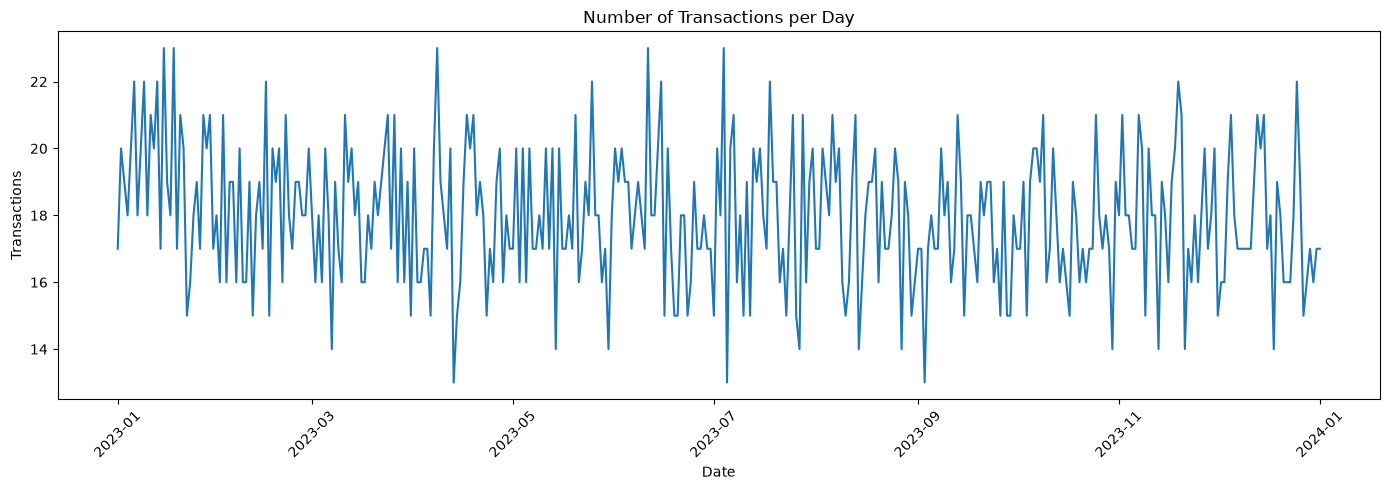

In [20]:
daily_transactions = (
    df.assign(
        Date=df["Date Time Served"].dt.date
    )
    .groupby("Date")
    .size()
)

display(daily_transactions.describe())

plt.figure(figsize=(14, 5))

daily_transactions.plot()

plt.title("Number of Transactions per Day")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Data Processing: Build Daily Demand Dataset

Pipeline: Raw CSV -> Validated records -> Daily aggregation -> Missing dates
filled -> Daily demand dataset -> EDA.

Important: a missing date does not automatically mean zero consumption. We
first measure date coverage per Bar x Brand, then decide how to complete the
calendar. Inventory balances are never blindly filled with zero.

In [21]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_processing import (
    prepare_raw_data,
    aggregate_daily_consumption
)

processed_df = prepare_raw_data(df)

daily_df = aggregate_daily_consumption(processed_df)

display(daily_df.head())

,Date,Bar Name,Brand Name,daily_consumption_ml,daily_purchase_ml,opening_inventory_ml,closing_inventory_ml,record_count
0,2023-01-01,Anderson's Bar,Bacardi,0.0,0.0,1109.09,1109.09,1
1,2023-01-01,Anderson's Bar,Jim Beam,0.0,0.0,872.08,872.08,1
2,2023-01-01,Anderson's Bar,Miller,0.0,0.0,1963.70,1963.70,1
3,2023-01-01,Anderson's Bar,Sutter Home,0.0,0.0,2017.45,2017.45,1
4,2023-01-01,Brown's Bar,Captain Morgan,0.0,0.0,2330.03,2330.03,1


In [22]:
coverage = (
    daily_df
    .groupby(["Bar Name", "Brand Name"])
    .agg(
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        observed_days=("Date", "nunique")
    )
    .reset_index()
)

coverage["calendar_days"] = (
    coverage["last_date"] - coverage["first_date"]
).dt.days + 1

coverage["coverage_pct"] = (
    coverage["observed_days"]
    / coverage["calendar_days"]
    * 100
)

display(
    coverage.sort_values("coverage_pct").head(20)
)

,Bar Name,Brand Name,first_date,last_date,observed_days,calendar_days,coverage_pct
71,Taylor's Bar,Heineken,2023-01-03,2023-12-02,40,334,11.976048
51,Smith's Bar,Budweiser,2023-01-03,2023-12-22,46,354,12.994350
21,Brown's Bar,Coors,2023-01-07,2023-12-25,46,353,13.031161
87,Thomas's Bar,Heineken,2023-01-08,2023-12-30,47,357,13.165266
53,Smith's Bar,Coors,2023-01-10,2023-12-28,47,353,13.314448
83,Thomas's Bar,Budweiser,2023-01-04,2023-12-25,48,356,13.483146
3,Anderson's Bar,Budweiser,2023-01-09,2023-12-26,48,352,13.636364
19,Brown's Bar,Budweiser,2023-01-06,2023-12-20,49,349,14.040115
55,Smith's Bar,Heineken,2023-01-08,2023-12-29,50,356,14.044944
35,Johnson's Bar,Budweiser,2023-01-13,2023-12-30,52,352,14.772727


In [23]:
def create_daily_calendar(daily_df: pd.DataFrame) -> pd.DataFrame:

    series_list = []

    for (bar, brand), group in daily_df.groupby(
        ["Bar Name", "Brand Name"]
    ):

        group = group.sort_values("Date").copy()

        full_dates = pd.date_range(
            start=group["Date"].min(),
            end=group["Date"].max(),
            freq="D"
        )

        group = (
            group
            .set_index("Date")
            .reindex(full_dates)
            .rename_axis("Date")
            .reset_index()
        )

        group["Bar Name"] = bar
        group["Brand Name"] = brand

        series_list.append(group)

    result = pd.concat(
        series_list,
        ignore_index=True
    )

    return result

In [24]:
daily_complete = create_daily_calendar(daily_df)

display(daily_complete.head(20))

,Date,Bar Name,Brand Name,daily_consumption_ml,daily_purchase_ml,opening_inventory_ml,closing_inventory_ml,record_count
0,2023-01-02,Anderson's Bar,Absolut,118.62,0.0,1.309920e+03,1.191300e+03,1.0
1,2023-01-03,Anderson's Bar,Absolut,NaN,NaN,NaN,NaN,NaN
2,2023-01-04,Anderson's Bar,Absolut,NaN,NaN,NaN,NaN,NaN
3,2023-01-05,Anderson's Bar,Absolut,463.20,0.0,1.191300e+03,7.281000e+02,1.0
4,2023-01-06,Anderson's Bar,Absolut,453.02,0.0,7.281000e+02,2.750800e+02,1.0
5,2023-01-07,Anderson's Bar,Absolut,NaN,NaN,NaN,NaN,NaN
6,2023-01-08,Anderson's Bar,Absolut,275.08,0.0,2.750800e+02,1.705303e-13,1.0
7,2023-01-09,Anderson's Bar,Absolut,NaN,NaN,NaN,NaN,NaN
8,2023-01-10,Anderson's Bar,Absolut,NaN,NaN,NaN,NaN,NaN
9,2023-01-11,Anderson's Bar,Absolut,0.00,0.0,1.705303e-13,1.705303e-13,1.0


In [25]:
daily_complete["daily_consumption_ml"] = (
    daily_complete["daily_consumption_ml"]
    .fillna(0)
)

daily_complete["daily_purchase_ml"] = (
    daily_complete["daily_purchase_ml"]
    .fillna(0)
)

# NOTE: opening/closing inventory are intentionally left as NaN on
# completed days -- missing inventory is NOT zero inventory.

In [26]:
daily_complete["day_of_week"] = (
    daily_complete["Date"].dt.dayofweek
)

daily_complete["day_name"] = (
    daily_complete["Date"].dt.day_name()
)

daily_complete["is_weekend"] = (
    daily_complete["day_of_week"] >= 5
)

daily_complete["week_of_year"] = (
    daily_complete["Date"].dt.isocalendar().week.astype(int)
)

daily_complete["month"] = (
    daily_complete["Date"].dt.month
)

In [27]:
daily_consumption = daily_complete[
    [
        "Date",
        "Bar Name",
        "Brand Name",
        "daily_consumption_ml",
        "daily_purchase_ml",
        "opening_inventory_ml",
        "closing_inventory_ml",
        "record_count",
        "day_of_week",
        "day_name",
        "is_weekend",
        "week_of_year",
        "month"
    ]
].copy()

daily_consumption = daily_consumption.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).reset_index(drop=True)

In [28]:
daily_consumption.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "daily_bar_consumption.csv"),
    index=False
)

print(daily_consumption.shape)
display(daily_consumption.head())

(34294, 13)


,Date,Bar Name,Brand Name,daily_consumption_ml,daily_purchase_ml,opening_inventory_ml,closing_inventory_ml,record_count,day_of_week,day_name,is_weekend,week_of_year,month
0,2023-01-02,Anderson's Bar,Absolut,118.62,0.0,1309.92,1191.30,1.0,0,Monday,False,1,1
1,2023-01-03,Anderson's Bar,Absolut,0.00,0.0,NaN,NaN,NaN,1,Tuesday,False,1,1
2,2023-01-04,Anderson's Bar,Absolut,0.00,0.0,NaN,NaN,NaN,2,Wednesday,False,1,1
3,2023-01-05,Anderson's Bar,Absolut,463.20,0.0,1191.30,728.10,1.0,3,Thursday,False,1,1
4,2023-01-06,Anderson's Bar,Absolut,453.02,0.0,728.10,275.08,1.0,4,Friday,False,1,1


In [29]:
print(
    "Negative consumption:",
    (daily_consumption["daily_consumption_ml"] < 0).sum()
)

raw_total = df["Consumed (ml)"].sum()

daily_total = (
    daily_consumption["daily_consumption_ml"].sum()
)

print("Raw total:", raw_total)
print("Daily total:", daily_total)
print("Difference:", raw_total - daily_total)

print(
    daily_consumption["Date"].min(),
    "to",
    daily_consumption["Date"].max()
)

print(
    daily_consumption
    .groupby(["Bar Name", "Brand Name"])
    .size()
    .describe()
)

Negative consumption: 0
Raw total: 1968681.66
Daily total: 1968681.6600000001
Difference: -2.3283064365386963e-10
2023-01-01 00:00:00 to 2024-01-01 00:00:00
count     96.000000
mean     357.229167
std        6.261796
min      334.000000
25%      353.750000
50%      358.000000
75%      362.000000
max      366.000000
dtype: float64


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if "PROJECT_ROOT" not in globals():
    from pathlib import Path

    def _find_project_root(start: Path) -> Path:
        for p in [start] + list(start.parents):
            if (p / "data" / "raw" / "bar_inventory_data.csv").exists():
                return p
        return start

    PROJECT_ROOT = _find_project_root(Path.cwd())

daily = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "daily_bar_consumption.csv",
    parse_dates=["Date"]
)

print(daily.shape)
display(daily.head())

(34294, 13)


,Date,Bar Name,Brand Name,daily_consumption_ml,daily_purchase_ml,opening_inventory_ml,closing_inventory_ml,record_count,day_of_week,day_name,is_weekend,week_of_year,month
0,2023-01-02,Anderson's Bar,Absolut,118.62,0.0,1309.92,1191.30,1.0,0,Monday,False,1,1
1,2023-01-03,Anderson's Bar,Absolut,0.00,0.0,NaN,NaN,NaN,1,Tuesday,False,1,1
2,2023-01-04,Anderson's Bar,Absolut,0.00,0.0,NaN,NaN,NaN,2,Wednesday,False,1,1
3,2023-01-05,Anderson's Bar,Absolut,463.20,0.0,1191.30,728.10,1.0,3,Thursday,False,1,1
4,2023-01-06,Anderson's Bar,Absolut,453.02,0.0,728.10,275.08,1.0,4,Friday,False,1,1


In [31]:
print("Date range:")
print(daily["Date"].min(), "to", daily["Date"].max())

print("\nBars:", daily["Bar Name"].nunique())
print("Brands:", daily["Brand Name"].nunique())

print(
    "Bar × Brand combinations:",
    daily[["Bar Name", "Brand Name"]].drop_duplicates().shape[0]
)

Date range:
2023-01-01 00:00:00 to 2024-01-01 00:00:00

Bars: 6
Brands: 16
Bar × Brand combinations: 96


## 6. Demand Analysis & EDA

Pipeline: daily demand dataset -> data quality -> overall consumption (total, by bar, by brand, by bar x brand) -> demand patterns (daily, weekly, weekend, monthly, variability) -> series classification (velocity / intermittent) -> forecasting strategy.

In [32]:
if "PROJECT_ROOT" not in globals():
    from pathlib import Path

    def _find_project_root(start: Path) -> Path:
        for p in [start] + list(start.parents):
            if (p / "data" / "raw" / "bar_inventory_data.csv").exists():
                return p
        return start

    PROJECT_ROOT = _find_project_root(Path.cwd())

daily = pd.read_csv(
    str(PROJECT_ROOT / "data" / "processed" / "daily_bar_consumption.csv"),
    parse_dates=["Date"]
)

print(daily.shape)
display(daily.head())

(34294, 13)


,Date,Bar Name,Brand Name,daily_consumption_ml,daily_purchase_ml,opening_inventory_ml,closing_inventory_ml,record_count,day_of_week,day_name,is_weekend,week_of_year,month
0,2023-01-02,Anderson's Bar,Absolut,118.62,0.0,1309.92,1191.30,1.0,0,Monday,False,1,1
1,2023-01-03,Anderson's Bar,Absolut,0.00,0.0,NaN,NaN,NaN,1,Tuesday,False,1,1
2,2023-01-04,Anderson's Bar,Absolut,0.00,0.0,NaN,NaN,NaN,2,Wednesday,False,1,1
3,2023-01-05,Anderson's Bar,Absolut,463.20,0.0,1191.30,728.10,1.0,3,Thursday,False,1,1
4,2023-01-06,Anderson's Bar,Absolut,453.02,0.0,728.10,275.08,1.0,4,Friday,False,1,1


In [33]:
print("Date range:")
print(daily["Date"].min(), "to", daily["Date"].max())

print("\nBars:", daily["Bar Name"].nunique())
print("Brands:", daily["Brand Name"].nunique())

print(
    "Bar x Brand combinations:",
    daily[["Bar Name", "Brand Name"]].drop_duplicates().shape[0]
)

Date range:
2023-01-01 00:00:00 to 2024-01-01 00:00:00

Bars: 6
Brands: 16
Bar x Brand combinations: 96


In [34]:
daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 34294 entries, 0 to 34293
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  34294 non-null  datetime64[us]
 1   Bar Name              34294 non-null  str           
 2   Brand Name            34294 non-null  str           
 3   daily_consumption_ml  34294 non-null  float64       
 4   daily_purchase_ml     34294 non-null  float64       
 5   opening_inventory_ml  6575 non-null   float64       
 6   closing_inventory_ml  6575 non-null   float64       
 7   record_count          6575 non-null   float64       
 8   day_of_week           34294 non-null  int64         
 9   day_name              34294 non-null  str           
 10  is_weekend            34294 non-null  bool          
 11  week_of_year          34294 non-null  int64         
 12  month                 34294 non-null  int64         
dtypes: bool(1), datetime64[us](

In [35]:
display(daily.describe(include="all"))

,Date,Bar Name,Brand Name,daily_consumption_ml,daily_purchase_ml,opening_inventory_ml,closing_inventory_ml,record_count,day_of_week,day_name,is_weekend,week_of_year,month
count,34294,34294,34294,34294.000000,34294.000000,6575.000000,6575.000000,6575.0,34294.000000,34294,34294,34294.000000,34294.000000
unique,NaN,6,16,NaN,NaN,NaN,NaN,NaN,NaN,7,2,NaN,NaN
top,NaN,Anderson's Bar,Malibu,NaN,NaN,NaN,NaN,NaN,NaN,Monday,False,NaN,NaN
freq,NaN,5740,2170,NaN,NaN,NaN,NaN,NaN,NaN,4906,24499,NaN,NaN
mean,2023-07-01 23:04:16.767947,NaN,NaN,57.406009,60.554603,2468.393518,2484.816011,1.0,2.999358,NaN,NaN,26.423135,6.519216
min,2023-01-01 00:00:00,NaN,NaN,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,NaN,NaN,1.000000,1.000000
25%,2023-04-04 00:00:00,NaN,NaN,0.000000,0.000000,619.135000,611.000000,1.0,1.000000,NaN,NaN,14.000000,4.000000
50%,2023-07-02 00:00:00,NaN,NaN,0.000000,0.000000,1848.440000,1849.840000,1.0,3.000000,NaN,NaN,26.000000,7.000000
75%,2023-09-29 00:00:00,NaN,NaN,0.000000,0.000000,3853.020000,3906.050000,1.0,5.000000,NaN,NaN,39.000000,9.000000
max,2024-01-01 00:00:00,NaN,NaN,1180.580000,1999.840000,11862.520000,11862.520000,1.0,6.000000,NaN,NaN,52.000000,12.000000


In [36]:
total_consumption = daily["daily_consumption_ml"].sum()

print(
    f"Total consumption: {total_consumption:,.2f} ml"
)

average_daily_consumption = (
    daily.groupby("Date")["daily_consumption_ml"]
    .sum()
    .mean()
)

print(
    f"Average daily consumption: "
    f"{average_daily_consumption:,.2f} ml"
)

Total consumption: 1,968,681.66 ml
Average daily consumption: 5,378.91 ml


,Date,daily_consumption_ml
0,2023-01-01,0.00
1,2023-01-02,6601.69
2,2023-01-03,7124.15
3,2023-01-04,6065.93
4,2023-01-05,8048.48


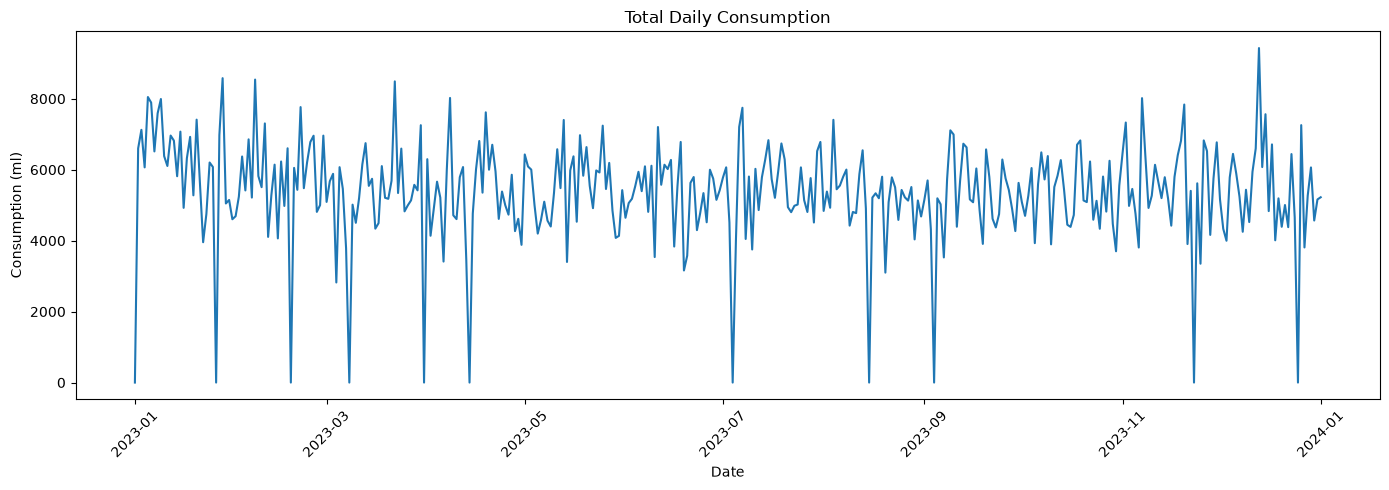

In [37]:
daily_total = (
    daily.groupby("Date")["daily_consumption_ml"]
    .sum()
    .reset_index()
)

display(daily_total.head())

plt.figure(figsize=(14, 5))

plt.plot(
    daily_total["Date"],
    daily_total["daily_consumption_ml"]
)

plt.title("Total Daily Consumption")
plt.xlabel("Date")
plt.ylabel("Consumption (ml)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Bar Name
Johnson's Bar     344184.38
Anderson's Bar    335818.95
Smith's Bar       328713.91
Brown's Bar       326371.92
Thomas's Bar      318415.94
Taylor's Bar      315176.56
Name: daily_consumption_ml, dtype: float64

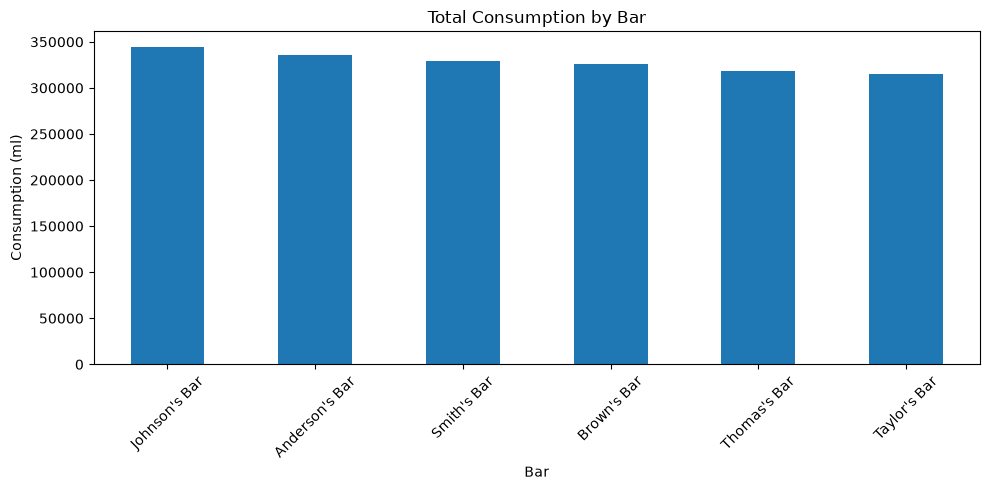

In [38]:
bar_consumption = (
    daily.groupby("Bar Name")["daily_consumption_ml"]
    .sum()
    .sort_values(ascending=False)
)

display(bar_consumption)

plt.figure(figsize=(10, 5))

bar_consumption.plot(kind="bar")

plt.title("Total Consumption by Bar")
plt.xlabel("Bar")
plt.ylabel("Consumption (ml)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Brand Name
Grey Goose        158924.02
Jim Beam          139702.43
Captain Morgan    138035.53
Barefoot          132312.95
Yellow Tail       129843.65
Smirnoff          129176.67
Bacardi           127951.80
Malibu            127279.51
Jack Daniels      125050.89
Absolut           123659.02
Jameson           120001.14
Sutter Home       117245.66
Miller            107719.33
Coors              97999.32
Heineken           96967.09
Budweiser          96812.65
Name: daily_consumption_ml, dtype: float64

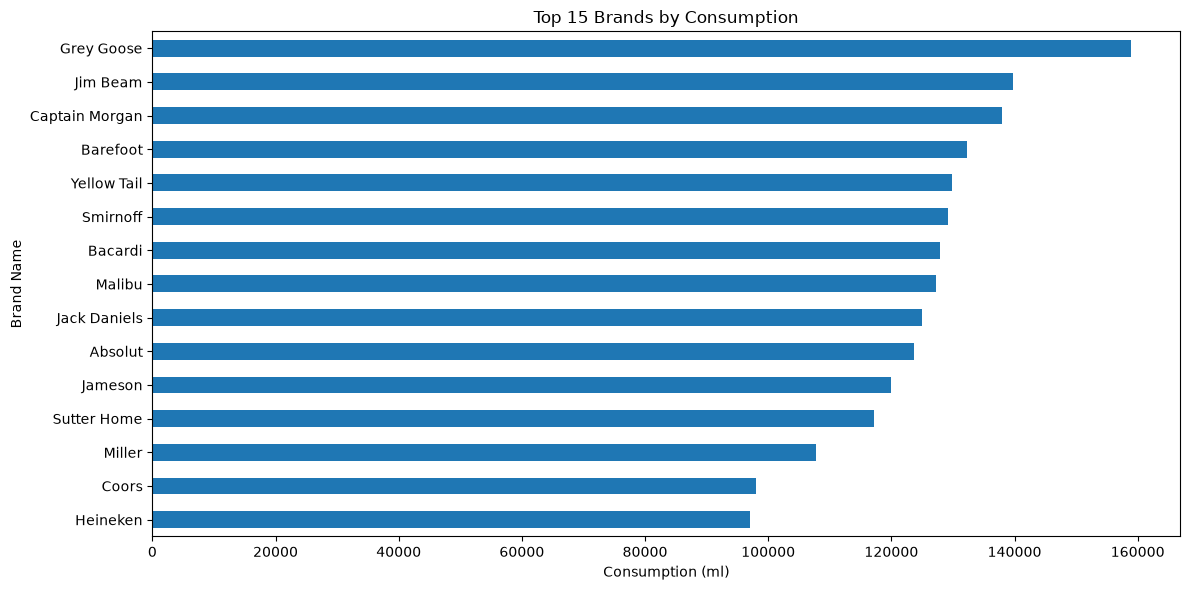

In [39]:
brand_consumption = (
    daily.groupby("Brand Name")["daily_consumption_ml"]
    .sum()
    .sort_values(ascending=False)
)

display(brand_consumption)

top_n = 15

plt.figure(figsize=(12, 6))

brand_consumption.head(top_n).sort_values().plot(
    kind="barh"
)

plt.title(f"Top {top_n} Brands by Consumption")
plt.xlabel("Consumption (ml)")

plt.tight_layout()
plt.show()

In [40]:
abc = (
    daily.groupby("Brand Name")["daily_consumption_ml"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

abc["consumption_share"] = (
    abc["daily_consumption_ml"]
    / abc["daily_consumption_ml"].sum()
)

abc["cumulative_share"] = (
    abc["consumption_share"].cumsum()
)

def classify_abc(cumulative_share):
    if cumulative_share <= 0.80:
        return "A"
    elif cumulative_share <= 0.95:
        return "B"
    else:
        return "C"

abc["ABC_class"] = (
    abc["cumulative_share"]
    .apply(classify_abc)
)

display(abc)

,Brand Name,daily_consumption_ml,consumption_share,cumulative_share,ABC_class
0,Grey Goose,158924.02,0.080726,0.080726,A
1,Jim Beam,139702.43,0.070962,0.151689,A
2,Captain Morgan,138035.53,0.070116,0.221804,A
3,Barefoot,132312.95,0.067209,0.289013,A
4,Yellow Tail,129843.65,0.065955,0.354968,A
5,Smirnoff,129176.67,0.065616,0.420584,A
6,Bacardi,127951.80,0.064994,0.485577,A
7,Malibu,127279.51,0.064652,0.550229,A
8,Jack Daniels,125050.89,0.063520,0.613750,A
9,Absolut,123659.02,0.062813,0.676563,A


day_name
Monday       55.199234
Tuesday      57.104176
Wednesday    59.625864
Thursday     56.699914
Friday       57.904938
Saturday     57.582208
Sunday       57.729318
Name: daily_consumption_ml, dtype: float64

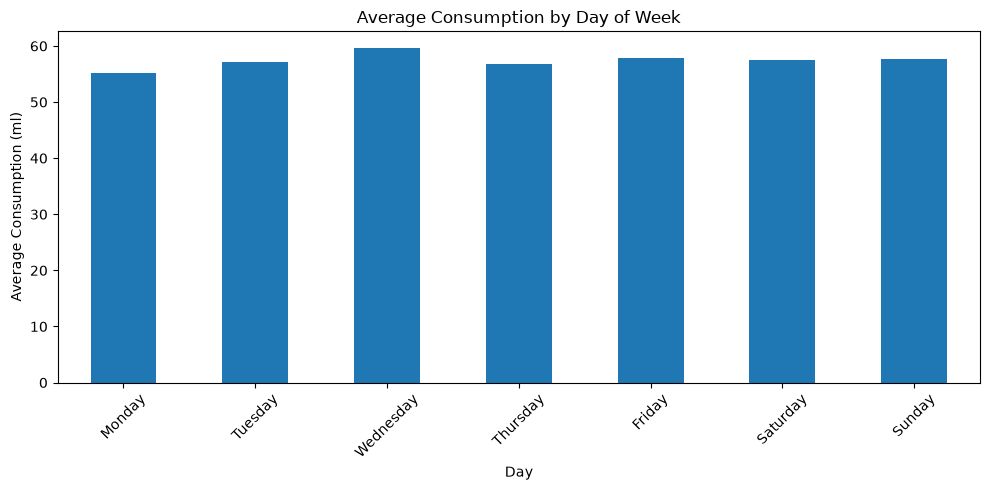

In [41]:
weekday_demand = (
    daily.groupby("day_name")["daily_consumption_ml"]
    .mean()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand = weekday_demand.reindex(weekday_order)

display(weekday_demand)

plt.figure(figsize=(10, 5))

weekday_demand.plot(kind="bar")

plt.title("Average Consumption by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Consumption (ml)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [42]:
weekend_analysis = (
    daily.groupby("is_weekend")["daily_consumption_ml"]
    .agg(["mean", "median", "std", "sum"])
)

display(weekend_analysis)

weekday_mean = daily.loc[
    ~daily["is_weekend"],
    "daily_consumption_ml"
].mean()

weekend_mean = daily.loc[
    daily["is_weekend"],
    "daily_consumption_ml"
].mean()

print("Weekday average:", weekday_mean)
print("Weekend average:", weekend_mean)

print(
    "Weekend / Weekday ratio:",
    weekend_mean / weekday_mean
)

,mean,median,std,sum
is_weekend,,,,
False,57.306145,0.0,144.631621,1403943.24
True,57.655786,0.0,145.060555,564738.42


Weekday average: 57.306144740601646
Weekend average: 57.655785604900466
Weekend / Weekday ratio: 1.0061012805150562


month
1     72.380316
2     59.457701
3     53.205632
4     54.118111
5     57.341882
6     55.238427
7     56.443763
8     52.907695
9     54.034094
10    55.234103
11    57.294090
12    63.728922
Name: daily_consumption_ml, dtype: float64

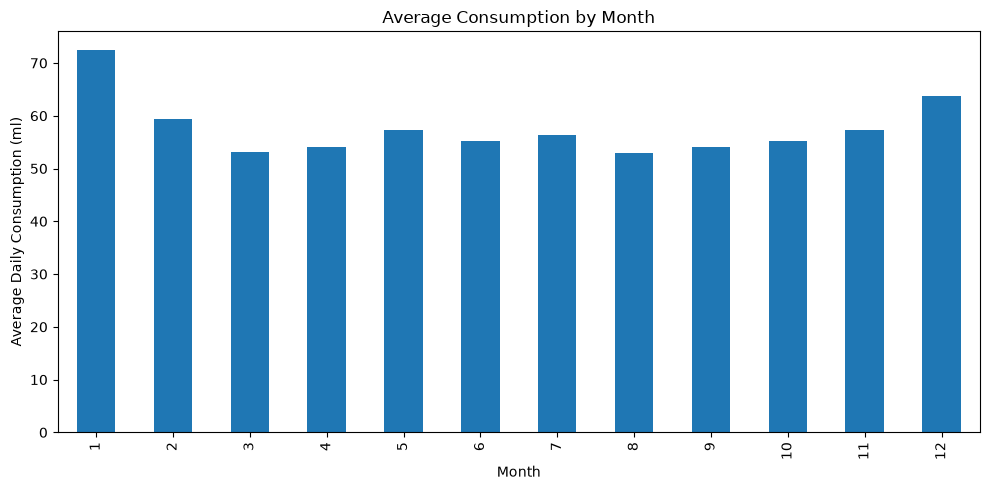

In [43]:
monthly_demand = (
    daily.groupby("month")["daily_consumption_ml"]
    .mean()
)

display(monthly_demand)

plt.figure(figsize=(10, 5))

monthly_demand.plot(kind="bar")

plt.title("Average Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Consumption (ml)")

plt.tight_layout()
plt.show()

In [44]:
series_summary = (
    daily
    .groupby(["Bar Name", "Brand Name"])
    .agg(
        total_consumption_ml=(
            "daily_consumption_ml",
            "sum"
        ),
        average_daily_consumption_ml=(
            "daily_consumption_ml",
            "mean"
        ),
        median_daily_consumption_ml=(
            "daily_consumption_ml",
            "median"
        ),
        std_daily_consumption_ml=(
            "daily_consumption_ml",
            "std"
        ),
        active_days=(
            "daily_consumption_ml",
            lambda x: (x > 0).sum()
        ),
        total_days=(
            "daily_consumption_ml",
            "size"
        )
    )
    .reset_index()
)

series_summary["active_day_pct"] = (
    series_summary["active_days"]
    / series_summary["total_days"]
    * 100
)

series_summary["coefficient_of_variation"] = (
    series_summary["std_daily_consumption_ml"]
    / series_summary["average_daily_consumption_ml"]
)

display(
    series_summary.sort_values(
        "total_consumption_ml",
        ascending=False
    ).head(20)
)

,Bar Name,Brand Name,total_consumption_ml,average_daily_consumption_ml,median_daily_consumption_ml,std_daily_consumption_ml,active_days,total_days,active_day_pct,coefficient_of_variation
31,Brown's Bar,Yellow Tail,29588.63,81.511377,0.0,172.158363,81,363,22.314050,2.112078
86,Thomas's Bar,Grey Goose,28510.30,79.415877,0.0,166.279164,79,359,22.005571,2.093777
36,Johnson's Bar,Captain Morgan,28319.66,78.884847,0.0,157.718235,86,359,23.955432,1.999348
70,Taylor's Bar,Grey Goose,28017.89,80.743199,0.0,168.088855,78,347,22.478386,2.081771
22,Brown's Bar,Grey Goose,27873.30,76.785950,0.0,170.511903,76,363,20.936639,2.220613
48,Smith's Bar,Absolut,27181.45,75.086878,0.0,161.753628,81,362,22.375691,2.154220
4,Anderson's Bar,Captain Morgan,27066.83,79.374868,0.0,177.002978,72,341,21.114370,2.229962
2,Anderson's Bar,Barefoot,26989.63,74.556989,0.0,160.246980,78,362,21.546961,2.149322
43,Johnson's Bar,Malibu,26356.51,72.407995,0.0,163.443248,67,364,18.406593,2.257254
32,Johnson's Bar,Absolut,26070.31,76.228977,0.0,156.621938,75,342,21.929825,2.054625


In [45]:
series_summary["zero_day_pct"] = (
    1
    - series_summary["active_days"]
    / series_summary["total_days"]
) * 100

display(
    series_summary.sort_values(
        "zero_day_pct",
        ascending=False
    ).head(20)
)

,Bar Name,Brand Name,total_consumption_ml,average_daily_consumption_ml,median_daily_consumption_ml,std_daily_consumption_ml,active_days,total_days,active_day_pct,coefficient_of_variation,zero_day_pct
3,Anderson's Bar,Budweiser,10062.29,28.586051,0.0,101.268097,32,352,9.090909,3.542570,90.909091
71,Taylor's Bar,Heineken,10108.67,30.265479,0.0,104.923793,31,334,9.281437,3.466781,90.718563
21,Brown's Bar,Coors,14029.01,39.742238,0.0,138.161618,36,353,10.198300,3.476443,89.801700
85,Thomas's Bar,Coors,13196.20,36.964146,0.0,116.758213,38,357,10.644258,3.158688,89.355742
87,Thomas's Bar,Heineken,13302.41,37.261653,0.0,118.503831,39,357,10.924370,3.180316,89.075630
83,Thomas's Bar,Budweiser,15071.10,42.334551,0.0,134.433687,39,356,10.955056,3.175508,89.044944
94,Thomas's Bar,Sutter Home,13964.45,38.575829,0.0,121.128936,40,362,11.049724,3.140022,88.950276
11,Anderson's Bar,Malibu,13594.76,37.763222,0.0,118.549731,40,360,11.111111,3.139291,88.888889
76,Taylor's Bar,Miller,14317.58,40.217921,0.0,127.023567,41,356,11.516854,3.158382,88.483146
53,Smith's Bar,Coors,15173.35,42.983994,0.0,125.963505,42,353,11.898017,2.930475,88.101983


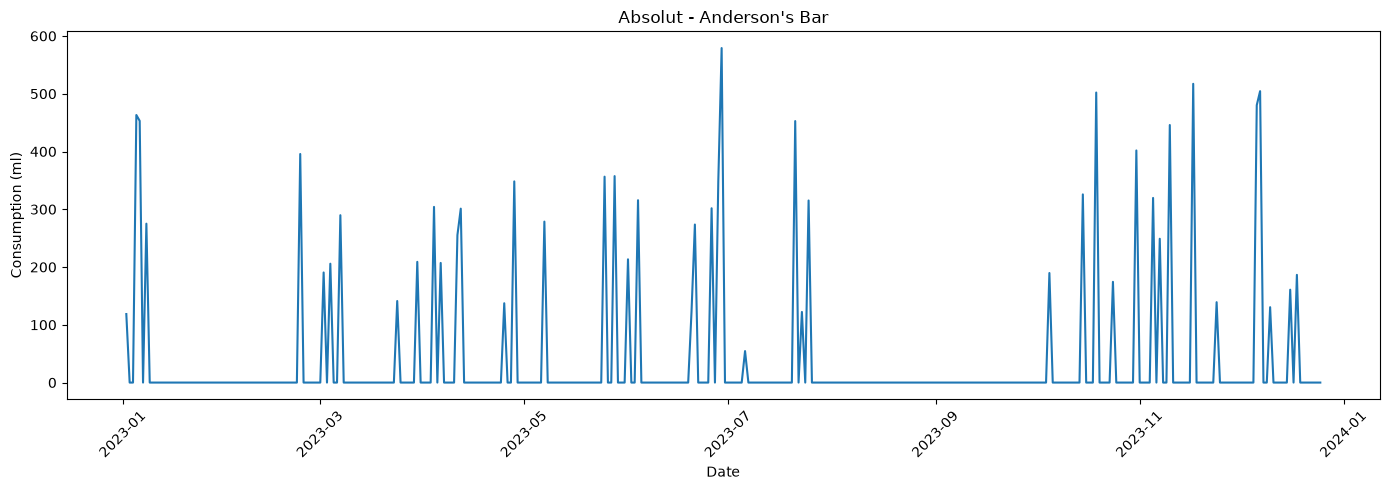

In [46]:
plt.figure(figsize=(14, 5))

for kind in ["High Velocity", "Medium Velocity"]:
    pass

sample_bar = daily["Bar Name"].iloc[0]
sample_brand = daily["Brand Name"].iloc[0]

sample_series = daily[
    (daily["Bar Name"] == sample_bar) &
    (daily["Brand Name"] == sample_brand)
].sort_values("Date")

plt.plot(
    sample_series["Date"],
    sample_series["daily_consumption_ml"]
)

plt.title(
    f"{sample_brand} - {sample_bar}"
)

plt.xlabel("Date")
plt.ylabel("Consumption (ml)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [47]:
variability = (
    daily.groupby(["Bar Name", "Brand Name"])
    ["daily_consumption_ml"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        max="max"
    )
    .reset_index()
)

variability["cv"] = (
    variability["std"]
    / variability["mean"]
)

display(
    variability.sort_values(
        "cv",
        ascending=False
    ).head(20)
)

,Bar Name,Brand Name,mean,std,min,max,cv
3,Anderson's Bar,Budweiser,28.586051,101.268097,0.0,574.10,3.542570
21,Brown's Bar,Coors,39.742238,138.161618,0.0,1024.38,3.476443
71,Taylor's Bar,Heineken,30.265479,104.923793,0.0,580.85,3.466781
87,Thomas's Bar,Heineken,37.261653,118.503831,0.0,850.54,3.180316
83,Thomas's Bar,Budweiser,42.334551,134.433687,0.0,1048.77,3.175508
85,Thomas's Bar,Coors,36.964146,116.758213,0.0,568.23,3.158688
76,Taylor's Bar,Miller,40.217921,127.023567,0.0,967.73,3.158382
94,Thomas's Bar,Sutter Home,38.575829,121.128936,0.0,569.26,3.140022
11,Anderson's Bar,Malibu,37.763222,118.549731,0.0,590.28,3.139291
78,Taylor's Bar,Sutter Home,43.701425,131.249784,0.0,1126.00,3.003330


In [48]:
def classify_demand(row):
    if row["active_day_pct"] < 30:
        return "Intermittent"
    elif row["average_daily_consumption_ml"] < 100:
        return "Low Velocity"
    elif row["average_daily_consumption_ml"] < 500:
        return "Medium Velocity"
    else:
        return "High Velocity"

series_summary["demand_class"] = (
    series_summary.apply(
        classify_demand,
        axis=1
    )
)

print(
    series_summary["demand_class"]
    .value_counts()
)

demand_class
Intermittent    96
Name: count, dtype: int64


In [49]:
series_summary.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "series_summary.csv"),
    index=False
)

abc.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "brand_abc_analysis.csv"),
    index=False
)

print("saved series_summary.csv and brand_abc_analysis.csv")

saved series_summary.csv and brand_abc_analysis.csv


## 6.5 Phase 3.5 — Intermittent Demand Analysis

We must not choose a forecasting model based only on the `active_day_pct < 30` rule. That rule only measures **how often** demand occurs. We also need to measure **how variable the amount is when demand actually happens**. These are two separate forecasting problems:

1. Will demand happen? (occurrence / intermittency)
2. How much will be consumed if it happens? (demand size)

This section inspects both dimensions and produces a 2-D classification (frequency / variability).


In [50]:
display(
    series_summary[
        [
            "Bar Name",
            "Brand Name",
            "active_days",
            "total_days",
            "active_day_pct",
            "zero_day_pct"
        ]
    ]
    .sort_values("active_day_pct")
    .head(30)
)

print("\nActive-day percentage statistics:")
display(series_summary["active_day_pct"].describe())


,Bar Name,Brand Name,active_days,total_days,active_day_pct,zero_day_pct
3,Anderson's Bar,Budweiser,32,352,9.090909,90.909091
71,Taylor's Bar,Heineken,31,334,9.281437,90.718563
21,Brown's Bar,Coors,36,353,10.198300,89.801700
85,Thomas's Bar,Coors,38,357,10.644258,89.355742
87,Thomas's Bar,Heineken,39,357,10.924370,89.075630
83,Thomas's Bar,Budweiser,39,356,10.955056,89.044944
94,Thomas's Bar,Sutter Home,40,362,11.049724,88.950276
11,Anderson's Bar,Malibu,40,360,11.111111,88.888889
76,Taylor's Bar,Miller,41,356,11.516854,88.483146
53,Smith's Bar,Coors,42,353,11.898017,88.101983



Active-day percentage statistics:


count    96.000000
mean     16.509172
std       3.262881
min       9.090909
25%      14.365189
50%      16.434668
75%      18.719310
max      23.955432
Name: active_day_pct, dtype: float64

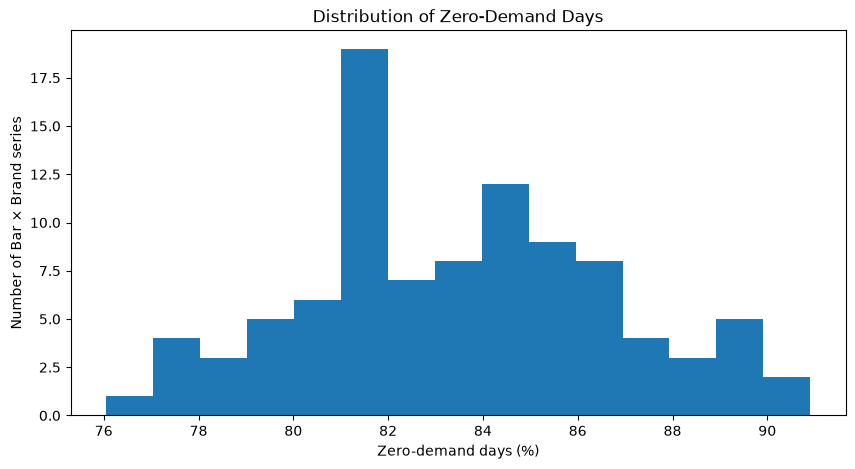

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    series_summary["zero_day_pct"],
    bins=15
)

plt.xlabel("Zero-demand days (%)")
plt.ylabel("Number of Bar × Brand series")
plt.title("Distribution of Zero-Demand Days")

plt.show()


In [52]:
top_series = (
    series_summary
    .sort_values("total_consumption_ml", ascending=False)
    .iloc[0]
)

sample_bar = top_series["Bar Name"]
sample_brand = top_series["Brand Name"]

print("Sample Bar:", sample_bar)
print("Sample Brand:", sample_brand)

sample = (
    daily[
        (daily["Bar Name"] == sample_bar) &
        (daily["Brand Name"] == sample_brand)
    ]
    .sort_values("Date")
)

display(
    sample[
        [
            "Date",
            "daily_consumption_ml",
            "daily_purchase_ml",
            "day_name"
        ]
    ].head(50)
)


Sample Bar: Brown's Bar
Sample Brand: Yellow Tail


,Date,daily_consumption_ml,daily_purchase_ml,day_name
11074,2023-01-02,535.95,0.00,Monday
11075,2023-01-03,0.00,0.00,Tuesday
11076,2023-01-04,0.00,0.00,Wednesday
11077,2023-01-05,552.50,0.00,Thursday
11078,2023-01-06,0.00,0.00,Friday
11079,2023-01-07,0.00,0.00,Saturday
11080,2023-01-08,0.00,0.00,Sunday
11081,2023-01-09,0.00,0.00,Monday
11082,2023-01-10,0.00,0.00,Tuesday
11083,2023-01-11,0.00,0.00,Wednesday


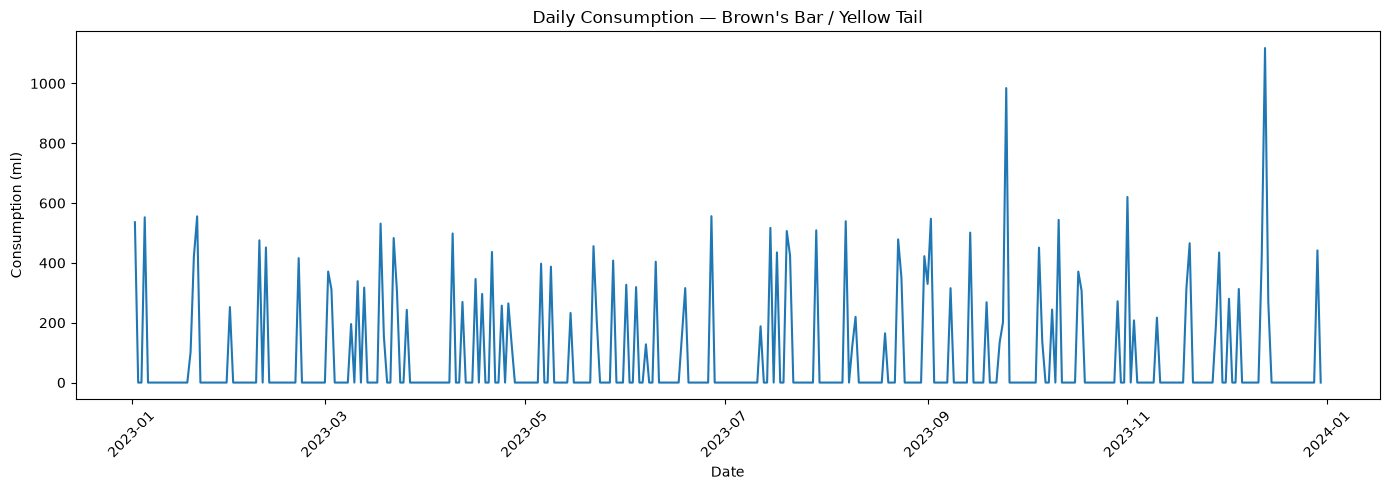

In [53]:
plt.figure(figsize=(14, 5))

plt.plot(
    sample["Date"],
    sample["daily_consumption_ml"]
)

plt.xlabel("Date")
plt.ylabel("Consumption (ml)")
plt.title(f"Daily Consumption — {sample_bar} / {sample_brand}")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [54]:
active_demand = daily[
    daily["daily_consumption_ml"] > 0
].copy()

active_demand_summary = (
    active_demand
    .groupby(["Bar Name", "Brand Name"])["daily_consumption_ml"]
    .agg(
        active_mean="mean",
        active_median="median",
        active_std="std",
        active_min="min",
        active_max="max"
    )
    .reset_index()
)

active_demand_summary["active_cv"] = (
    active_demand_summary["active_std"] /
    active_demand_summary["active_mean"]
)

display(
    active_demand_summary
    .sort_values("active_cv", ascending=False)
    .head(20)
)


,Bar Name,Brand Name,active_mean,active_median,active_std,active_min,active_max,active_cv
68,Taylor's Bar,Captain Morgan,344.948636,304.470,202.802321,58.54,1077.89,0.587920
21,Brown's Bar,Coors,389.694722,303.295,227.389644,100.27,1024.38,0.583507
57,Smith's Bar,Jameson,334.878889,340.400,187.861405,99.12,940.78,0.560983
61,Smith's Bar,Smirnoff,333.690196,279.370,186.187210,30.54,1001.93,0.557964
15,Anderson's Bar,Yellow Tail,352.857679,367.140,195.193109,2.14,1036.72,0.553178
95,Thomas's Bar,Yellow Tail,317.143966,299.695,170.286577,95.62,929.75,0.536938
12,Anderson's Bar,Miller,371.026531,395.660,197.591857,28.72,983.79,0.532555
34,Johnson's Bar,Barefoot,334.653485,319.005,178.032062,105.83,1176.86,0.531989
44,Johnson's Bar,Miller,340.109583,308.360,179.987885,52.81,934.57,0.529206
65,Taylor's Bar,Bacardi,312.713585,292.200,163.403622,21.16,765.39,0.522534


In [55]:
# Self-heal: regenerate active-demand metrics if Step 4 output is missing
required_active_cols = {
    "active_mean", "active_median", "active_std",
    "active_min", "active_max", "active_cv"
}
if ("active_demand_summary" not in globals()
        or not required_active_cols.issubset(active_demand_summary.columns)):
    active_demand = daily[daily["daily_consumption_ml"] > 0].copy()
    active_demand_summary = (
        active_demand
        .groupby(["Bar Name", "Brand Name"])["daily_consumption_ml"]
        .agg(
            active_mean="mean",
            active_median="median",
            active_std="std",
            active_min="min",
            active_max="max"
        )
        .reset_index()
    )
    active_demand_summary["active_cv"] = (
        active_demand_summary["active_std"]
        / active_demand_summary["active_mean"]
    )

# Idempotency: if a previous run already merged these columns, drop them first
prior_cols = [c for c in ["active_mean", "active_median", "active_std",
                          "active_min", "active_max", "active_cv",
                          "demand_frequency", "demand_variability", "demand_class"]
              if c in series_summary.columns]
if prior_cols:
    series_summary = series_summary.drop(columns=prior_cols)

series_summary = series_summary.merge(
    active_demand_summary[
        [
            "Bar Name",
            "Brand Name",
            "active_mean",
            "active_median",
            "active_std",
            "active_min",
            "active_max",
            "active_cv"
        ]
    ],
    on=["Bar Name", "Brand Name"],
    how="left"
)

display(
    series_summary[
        [
            "Bar Name",
            "Brand Name",
            "active_day_pct",
            "zero_day_pct",
            "active_mean",
            "active_median",
            "active_cv"
        ]
    ].head(20)
)

def classify_frequency(pct):
    if pct >= 30:
        return "Frequent"
    elif pct >= 10:
        return "Occasional"
    else:
        return "Intermittent"

def classify_variability(cv):
    if cv < 0.5:
        return "Low Variability"
    elif cv < 1.0:
        return "Medium Variability"
    else:
        return "High Variability"

series_summary["demand_frequency"] = (
    series_summary["active_day_pct"].apply(classify_frequency)
)
series_summary["demand_variability"] = (
    series_summary["active_cv"].apply(classify_variability)
)
series_summary["demand_class"] = (
    series_summary["demand_frequency"]
    + " / "
    + series_summary["demand_variability"]
)

print(series_summary["demand_class"].value_counts())

if "PROJECT_ROOT" not in globals():
    from pathlib import Path

    def _find_project_root(start: Path) -> Path:
        for p in [start] + list(start.parents):
            if (p / "data" / "raw" / "bar_inventory_data.csv").exists():
                return p
        return start

    PROJECT_ROOT = _find_project_root(Path.cwd())

series_summary.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "series_summary.csv"),
    index=False
)

print("Updated series_summary.csv saved.")


,Bar Name,Brand Name,active_day_pct,zero_day_pct,active_mean,active_median,active_cv
0,Anderson's Bar,Absolut,12.569832,87.430168,291.420222,289.730,0.444401
1,Anderson's Bar,Bacardi,18.904110,81.095890,376.325652,386.250,0.374894
2,Anderson's Bar,Barefoot,21.546961,78.453039,346.020897,351.220,0.459133
3,Anderson's Bar,Budweiser,9.090909,90.909091,314.446563,274.905,0.485728
4,Anderson's Bar,Captain Morgan,21.114370,78.885630,375.928194,349.620,0.511527
5,Anderson's Bar,Coors,15.890411,84.109589,370.332586,390.515,0.360270
6,Anderson's Bar,Grey Goose,18.539326,81.460674,364.035758,374.675,0.397523
7,Anderson's Bar,Heineken,12.640449,87.359551,386.971333,385.500,0.347805
8,Anderson's Bar,Jack Daniels,18.105850,81.894150,330.066462,292.530,0.493176
9,Anderson's Bar,Jameson,18.662953,81.337047,345.031343,327.160,0.484959


demand_class
Occasional / Low Variability       75
Occasional / Medium Variability    19
Intermittent / Low Variability      2
Name: count, dtype: int64
Updated series_summary.csv saved.


In [56]:
sample_weekday = (
    sample
    .groupby("day_name")["daily_consumption_ml"]
    .agg(
        mean="mean",
        median="median",
        total="sum"
    )
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

display(sample_weekday)

sample_active_weekday = (
    sample[sample["daily_consumption_ml"] > 0]
    .groupby("day_name")["daily_consumption_ml"]
    .agg(
        active_mean="mean",
        active_median="median",
        active_total="sum",
        active_days="count"
    )
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

display(sample_active_weekday)


,mean,median,total
day_name,,,
Monday,91.992885,0.0,4783.63
Tuesday,70.733846,0.0,3678.16
Wednesday,95.363846,0.0,4958.92
Thursday,99.603462,0.0,5179.38
Friday,62.338846,0.0,3241.62
Saturday,92.938846,0.0,4832.82
Sunday,57.139216,0.0,2914.10


,active_mean,active_median,active_total,active_days
day_name,,,,
Monday,434.875455,435.170,4783.63,11
Tuesday,334.378182,312.900,3678.16,11
Wednesday,413.243333,370.875,4958.92,12
Thursday,345.292000,350.380,5179.38,15
Friday,324.162000,322.605,3241.62,10
Saturday,402.735000,427.830,4832.82,12
Sunday,291.410000,293.135,2914.10,10


In [57]:
intermittent_analysis = series_summary[
    [
        "Bar Name",
        "Brand Name",
        "active_days",
        "total_days",
        "active_day_pct",
        "zero_day_pct",
        "total_consumption_ml",
        "average_daily_consumption_ml",
        "std_daily_consumption_ml",
        "coefficient_of_variation",
        "active_mean",
        "active_median",
        "active_std",
        "active_cv",
        "demand_frequency",
        "demand_variability",
        "demand_class"
    ]
].copy()

if "PROJECT_ROOT" not in globals():
    from pathlib import Path

    def _find_project_root(start: Path) -> Path:
        for p in [start] + list(start.parents):
            if (p / "data" / "raw" / "bar_inventory_data.csv").exists():
                return p
        return start

    PROJECT_ROOT = _find_project_root(Path.cwd())

intermittent_analysis.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "intermittent_demand_analysis.csv"),
    index=False
)

print("Saved:")
print(str(PROJECT_ROOT / "data" / "processed" / "intermittent_demand_analysis.csv"))


Saved:
C:\Users\ASWIN\Documents\Personal\New folder\bar_inventory_project\data\processed\intermittent_demand_analysis.csv


## 7. Phase 4 — Forecasting Strategy

Objective: historical daily consumption -> baseline -> intermittent-demand model -> time-based backtesting -> compare MAE / RMSE / WAPE -> select a model per Bar x Brand.

Phase 3.5 showed the overall CV around 3 was inflated by heavy zero days; active-day CVs are at most about 0.59. So a complicated ML model is not justified out of the gate. We start with simple baselines and let time-based backtesting (never random splits) decide whether extra complexity actually improves the forecast.


In [58]:
import pandas as pd
import numpy as np

FORECAST_HORIZON = 30

def time_split_series(series, forecast_horizon=30):
    series = series.sort_values("Date").copy()

    if len(series) <= forecast_horizon:
        return None, None

    train = series.iloc[:-forecast_horizon].copy()
    test = series.iloc[-forecast_horizon:].copy()

    return train, test


In [59]:
def mean_forecast(train, horizon):
    mean_demand = train["daily_consumption_ml"].mean()

    return np.repeat(
        mean_demand,
        horizon
    )


In [60]:
def intermittent_mean_forecast(train, horizon):
    demand = train["daily_consumption_ml"]

    probability_demand = (demand > 0).mean()

    active_demand = demand[demand > 0]

    if len(active_demand) == 0:
        return np.zeros(horizon)

    active_mean = active_demand.mean()

    expected_daily_demand = (
        probability_demand * active_mean
    )

    return np.repeat(
        expected_daily_demand,
        horizon
    )


In [61]:
def moving_average_forecast(train, horizon, window=14):
    demand = train["daily_consumption_ml"]

    window = min(window, len(demand))

    forecast_value = demand.tail(window).mean()

    return np.repeat(
        forecast_value,
        horizon
    )


In [62]:
def mae(y_true, y_pred):
    return np.mean(
        np.abs(y_true - y_pred)
    )

def rmse(y_true, y_pred):
    return np.sqrt(
        np.mean(
            (y_true - y_pred) ** 2
        )
    )

def wape(y_true, y_pred):
    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return (
        np.sum(np.abs(y_true - y_pred))
        / denominator
    )


### 4.2 — Intermittent-demand models (Croston / SBA / TSB-style)

These models were designed for zero-heavy demand, which our data clearly is. WAPE is only compared among series where total actual demand > 0 (it is undefined otherwise).


In [63]:
def croston_forecast(train, horizon, alpha=0.1):
    """
    Croston's method for intermittent demand.

    Separately estimates:
    - demand size
    - interval between non-zero demands
    """

    demand = train["daily_consumption_ml"].values

    non_zero = demand[demand > 0]

    if len(non_zero) == 0:
        return np.zeros(horizon)

    # First non-zero demand
    first_index = np.where(demand > 0)[0][0]

    z = demand[first_index]   # demand estimate
    p = first_index + 1       # interval estimate

    interval = 0

    for t in range(first_index + 1, len(demand)):

        if demand[t] > 0:

            interval += 1

            z = (
                alpha * demand[t]
                + (1 - alpha) * z
            )

            p = (
                alpha * interval
                + (1 - alpha) * p
            )

            interval = 0

        else:
            interval += 1

    forecast_value = z / p if p > 0 else 0

    return np.repeat(
        forecast_value,
        horizon
    )


In [64]:
def sba_forecast(train, horizon, alpha=0.1):
    """
    Syntetos-Boylan Approximation (SBA)
    """

    demand = train["daily_consumption_ml"].values

    if np.sum(demand > 0) == 0:
        return np.zeros(horizon)

    first_index = np.where(demand > 0)[0][0]

    z = demand[first_index]
    p = first_index + 1

    interval = 0

    for t in range(first_index + 1, len(demand)):

        if demand[t] > 0:

            interval += 1

            z = (
                alpha * demand[t]
                + (1 - alpha) * z
            )

            p = (
                alpha * interval
                + (1 - alpha) * p
            )

            interval = 0

        else:
            interval += 1

    forecast_value = (
        (1 - alpha / 2)
        * z
        / p
    )

    return np.repeat(
        forecast_value,
        horizon
    )


In [65]:
results = []

for (bar, brand), group in daily.groupby(
    ["Bar Name", "Brand Name"]
):

    group = group.sort_values("Date").reset_index(drop=True)

    train, test = time_split_series(
        group,
        forecast_horizon=FORECAST_HORIZON
    )

    if train is None:
        continue

    y_true = test["daily_consumption_ml"].values

    forecasts = {
        "Mean": mean_forecast(train, FORECAST_HORIZON),

        "Intermittent Mean": intermittent_mean_forecast(
            train,
            FORECAST_HORIZON
        ),

        "MA-7": moving_average_forecast(
            train,
            FORECAST_HORIZON,
            window=7
        ),

        "MA-14": moving_average_forecast(
            train,
            FORECAST_HORIZON,
            window=14
        ),

        "MA-30": moving_average_forecast(
            train,
            FORECAST_HORIZON,
            window=30
        ),

        "Croston": croston_forecast(
            train,
            FORECAST_HORIZON
        ),

        "SBA": sba_forecast(
            train,
            FORECAST_HORIZON
        ),
    }

    for model_name, prediction in forecasts.items():

        results.append({
            "Bar Name": bar,
            "Brand Name": brand,
            "Model": model_name,
            "MAE": mae(y_true, prediction),
            "RMSE": rmse(y_true, prediction),
            "WAPE": wape(y_true, prediction),
        })

forecast_results = pd.DataFrame(results)

display(
    forecast_results.head()
)


,Bar Name,Brand Name,Model,MAE,RMSE,WAPE
0,Anderson's Bar,Absolut,Mean,72.428911,128.670276,1.485813
1,Anderson's Bar,Absolut,Intermittent Mean,72.428911,128.670276,1.485813
2,Anderson's Bar,Absolut,MA-7,62.000333,131.203910,1.271880
3,Anderson's Bar,Absolut,MA-14,80.002238,128.002489,1.641173
4,Anderson's Bar,Absolut,MA-30,94.805889,129.595262,1.944856


In [66]:
valid_results = forecast_results.dropna(
    subset=["WAPE"]
)

model_summary = (
    valid_results
    .groupby("Model")
    .agg(
        series_count=("Model", "size"),
        mean_MAE=("MAE", "mean"),
        median_MAE=("MAE", "median"),
        mean_RMSE=("RMSE", "mean"),
        median_RMSE=("RMSE", "median"),
        mean_WAPE=("WAPE", "mean"),
        median_WAPE=("WAPE", "median")
    )
    .sort_values("mean_WAPE")
)

display(model_summary)


,series_count,mean_MAE,median_MAE,mean_RMSE,median_RMSE,mean_WAPE,median_WAPE
Model,,,,,,,
MA-7,94,99.543499,98.861857,157.669541,154.225286,1.710614,1.343214
MA-14,94,99.693750,97.141452,153.817847,154.123220,1.727522,1.480932
MA-30,94,101.079408,99.906289,150.824098,150.889897,1.738397,1.520022
Intermittent Mean,94,99.965160,98.267483,148.385761,145.871837,1.783336,1.537972
Mean,94,99.965160,98.267483,148.385761,145.871837,1.783336,1.537972
SBA,94,100.238794,98.814543,149.278851,147.939764,1.794347,1.551394
Croston,94,102.122813,100.831433,149.402634,148.212980,1.836606,1.580415


In [67]:
best_models = (
    valid_results
    .sort_values(
        ["Bar Name", "Brand Name", "WAPE"]
    )
    .groupby(
        ["Bar Name", "Brand Name"],
        as_index=False
    )
    .first()
)

display(best_models.head(20))

print(
    best_models["Model"]
    .value_counts()
)


,Bar Name,Brand Name,Model,MAE,RMSE,WAPE
0,Anderson's Bar,Absolut,MA-7,62.000333,131.203910,1.271880
1,Anderson's Bar,Bacardi,MA-30,123.292533,203.494026,1.129611
2,Anderson's Bar,Barefoot,MA-7,79.952714,127.324464,1.313564
3,Anderson's Bar,Captain Morgan,MA-7,95.274667,144.049020,1.205907
4,Anderson's Bar,Coors,MA-7,100.755000,212.217390,1.000000
5,Anderson's Bar,Grey Goose,MA-14,57.920048,98.995173,1.438852
6,Anderson's Bar,Heineken,MA-7,63.154000,165.759853,1.000000
7,Anderson's Bar,Jack Daniels,Mean,90.015409,112.755271,1.672082
8,Anderson's Bar,Jameson,SBA,89.269158,123.180068,1.821250
9,Anderson's Bar,Jim Beam,Intermittent Mean,140.450149,203.146386,1.236270


Model
MA-7                 45
MA-30                16
SBA                  11
MA-14                10
Mean                  9
Intermittent Mean     3
Name: count, dtype: int64


In [68]:
forecast_results.to_csv(
    PROJECT_ROOT / "data" / "processed" / "forecast_model_results.csv",
    index=False
)

best_models.to_csv(
    PROJECT_ROOT / "data" / "processed" / "best_forecasting_models.csv",
    index=False
)

print("Forecast evaluation results saved.")


Forecast evaluation results saved.


## 8. Phase 5 — Rolling Backtest & Final Model Selection

A single 30-day holdout is a first experiment; a production model should earn its place over **several historical test windows**. Rolling-origin backtesting creates multiple 'past future' periods so the per-series model choice is defensible, not accidental.


In [69]:
def rolling_time_splits(
    series,
    forecast_horizon=30,
    n_splits=4,
    min_train_size=90
):
    series = (
        series
        .sort_values("Date")
        .reset_index(drop=True)
    )

    total_length = len(series)

    splits = []

    for i in range(n_splits):

        test_end = (
            total_length
            - i * forecast_horizon
        )

        test_start = (
            test_end
            - forecast_horizon
        )

        if test_start < min_train_size:
            break

        train = series.iloc[:test_start].copy()

        test = series.iloc[
            test_start:test_end
        ].copy()

        splits.append(
            (train, test)
        )

    return list(reversed(splits))


In [70]:
def generate_forecast(
    model_name,
    train,
    horizon
):

    if model_name == "Mean":
        return mean_forecast(
            train,
            horizon
        )

    elif model_name == "Intermittent Mean":
        return intermittent_mean_forecast(
            train,
            horizon
        )

    elif model_name == "MA-7":
        return moving_average_forecast(
            train,
            horizon,
            window=7
        )

    elif model_name == "MA-14":
        return moving_average_forecast(
            train,
            horizon,
            window=14
        )

    elif model_name == "MA-30":
        return moving_average_forecast(
            train,
            horizon,
            window=30
        )

    elif model_name == "Croston":
        return croston_forecast(
            train,
            horizon
        )

    elif model_name == "SBA":
        return sba_forecast(
            train,
            horizon
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )


In [71]:
rolling_results = []

for (bar, brand), group in daily.groupby(
    ["Bar Name", "Brand Name"]
):

    group = (
        group
        .sort_values("Date")
        .reset_index(drop=True)
    )

    splits = rolling_time_splits(
        group,
        forecast_horizon=30,
        n_splits=4,
        min_train_size=90
    )

    for fold, (train, test) in enumerate(
        splits,
        start=1
    ):

        y_true = (
            test["daily_consumption_ml"]
            .values
        )

        for model_name in [
            "Mean",
            "Intermittent Mean",
            "MA-7",
            "MA-14",
            "MA-30",
            "Croston",
            "SBA"
        ]:

            prediction = generate_forecast(
                model_name,
                train,
                len(test)
            )

            rolling_results.append({
                "Bar Name": bar,
                "Brand Name": brand,
                "Fold": fold,
                "Model": model_name,
                "MAE": mae(
                    y_true,
                    prediction
                ),
                "RMSE": rmse(
                    y_true,
                    prediction
                ),
                "WAPE": wape(
                    y_true,
                    prediction
                )
            })

rolling_results = pd.DataFrame(
    rolling_results
)

display(
    rolling_results.head()
)


,Bar Name,Brand Name,Fold,Model,MAE,RMSE,WAPE
0,Anderson's Bar,Absolut,1,Mean,35.239286,35.239286,NaN
1,Anderson's Bar,Absolut,1,Intermittent Mean,35.239286,35.239286,NaN
2,Anderson's Bar,Absolut,1,MA-7,0.000000,0.000000,NaN
3,Anderson's Bar,Absolut,1,MA-14,0.000000,0.000000,NaN
4,Anderson's Bar,Absolut,1,MA-30,0.000000,0.000000,NaN


In [72]:
rolling_summary = (
    rolling_results
    .dropna(subset=["WAPE"])
    .groupby("Model")
    .agg(
        folds=("Model", "size"),
        mean_MAE=("MAE", "mean"),
        median_MAE=("MAE", "median"),
        mean_RMSE=("RMSE", "mean"),
        median_RMSE=("RMSE", "median"),
        mean_WAPE=("WAPE", "mean"),
        median_WAPE=("WAPE", "median")
    )
    .sort_values("mean_WAPE")
)

display(rolling_summary)


,folds,mean_MAE,median_MAE,mean_RMSE,median_RMSE,mean_WAPE,median_WAPE
Model,,,,,,,
MA-30,370,96.054817,95.101922,144.194100,142.473944,1.992375,1.582856
MA-14,370,94.760927,92.402119,146.962598,144.031299,2.011498,1.555002
MA-7,370,95.589846,92.778024,151.727234,151.616792,2.014236,1.402159
SBA,370,96.568873,95.459708,142.686969,139.853129,2.045517,1.638551
Mean,370,96.842923,95.769607,142.264235,139.102561,2.050015,1.644375
Intermittent Mean,370,96.842923,95.769607,142.264235,139.102561,2.050015,1.644375
Croston,370,98.515977,97.006563,142.872653,140.324373,2.100971,1.672158


In [73]:
series_model_scores = (
    rolling_results
    .dropna(subset=["WAPE"])
    .groupby(
        ["Bar Name", "Brand Name", "Model"]
    )
    .agg(
        mean_WAPE=("WAPE", "mean"),
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        folds=("WAPE", "count")
    )
    .reset_index()
)

final_model_selection = (
    series_model_scores
    .sort_values(
        [
            "Bar Name",
            "Brand Name",
            "mean_WAPE"
        ]
    )
    .groupby(
        ["Bar Name", "Brand Name"],
        as_index=False
    )
    .first()
)

display(
    final_model_selection.head(20)
)

print(
    final_model_selection["Model"]
    .value_counts()
)


,Bar Name,Brand Name,Model,mean_WAPE,mean_MAE,mean_RMSE,folds
0,Anderson's Bar,Absolut,MA-7,1.162746,61.922127,135.266953,3
1,Anderson's Bar,Bacardi,MA-7,1.496620,74.669179,136.827035,4
2,Anderson's Bar,Barefoot,MA-7,1.273172,120.156774,183.840515,4
3,Anderson's Bar,Budweiser,MA-7,3.235469,57.847976,82.788483,2
4,Anderson's Bar,Captain Morgan,MA-14,1.487286,118.740024,167.246279,4
5,Anderson's Bar,Coors,MA-7,1.483988,52.357298,114.112988,4
6,Anderson's Bar,Grey Goose,MA-30,1.969110,87.453911,127.960776,4
7,Anderson's Bar,Heineken,MA-14,1.577395,42.997083,117.532278,4
8,Anderson's Bar,Jack Daniels,Intermittent Mean,1.457363,105.578183,163.644711,4
9,Anderson's Bar,Jameson,MA-30,1.696753,93.831561,136.839590,4


Model
MA-7                 34
Intermittent Mean    20
MA-30                19
MA-14                13
SBA                   7
Mean                  3
Name: count, dtype: int64


## 9. Phase 5 — Final 30-Day Demand Forecast

We now stop asking "which model performs best historically?" and answer: "using the selected model, what demand should we expect for each Bar × Brand over the next 30 days?"

Historical consumption -> rolling backtesting -> best model per Bar × Brand -> train selected model on ALL history -> 30-day forecast -> forecast uncertainty -> lead-time demand -> safety stock -> reorder point -> par level.

Two honest caveats carry into the inventory policy:

1. **WAPE is frequently above 1.0** (e.g., Anderson's Bar / Malibu, Intermittent Mean, WAPE ≈ 6.9). Point forecasts are inherently uncertain for highly intermittent series; we must not hide that. The policy absorbs this uncertainty through safety stock rather than pretending forecasts are exact.
2. **Observed zeros may be censored demand** — if opening stock runs out, *consumed = closing = 0* can mean the sale was constrained by inventory, not that demand was zero. Phase 6 starts with a stockout/censoring check before anything is plugged into the safety-stock formula.


### 5.1 — Train the selected model on all history


In [74]:
FORECAST_HORIZON = 30

final_forecasts = []

for (bar, brand), group in daily.groupby(
    ["Bar Name", "Brand Name"]
):

    group = (
        group
        .sort_values("Date")
        .reset_index(drop=True)
    )

    # Find selected model
    selected = final_model_selection[
        (final_model_selection["Bar Name"] == bar)
        & (final_model_selection["Brand Name"] == brand)
    ]

    if selected.empty:
        continue

    model_name = selected.iloc[0]["Model"]

    # Generate forecast using ALL available history
    prediction = generate_forecast(
        model_name,
        group,
        FORECAST_HORIZON
    )

    last_date = group["Date"].max()

    forecast_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=FORECAST_HORIZON,
        freq="D"
    )

    for date, forecast_value in zip(
        forecast_dates,
        prediction
    ):
        final_forecasts.append({
            "Bar Name": bar,
            "Brand Name": brand,
            "Date": date,
            "Selected Model": model_name,
            "Forecast Consumption (ml)": max(
                0,
                forecast_value
            )
        })

final_forecasts = pd.DataFrame(final_forecasts)

display(final_forecasts.head(30))

print(final_forecasts.shape)

print(final_forecasts["Selected Model"].value_counts())



,Bar Name,Brand Name,Date,Selected Model,Forecast Consumption (ml)
0,Anderson's Bar,Absolut,2023-12-26,MA-7,0.0
1,Anderson's Bar,Absolut,2023-12-27,MA-7,0.0
2,Anderson's Bar,Absolut,2023-12-28,MA-7,0.0
3,Anderson's Bar,Absolut,2023-12-29,MA-7,0.0
4,Anderson's Bar,Absolut,2023-12-30,MA-7,0.0
5,Anderson's Bar,Absolut,2023-12-31,MA-7,0.0
6,Anderson's Bar,Absolut,2024-01-01,MA-7,0.0
7,Anderson's Bar,Absolut,2024-01-02,MA-7,0.0
8,Anderson's Bar,Absolut,2024-01-03,MA-7,0.0
9,Anderson's Bar,Absolut,2024-01-04,MA-7,0.0


(2880, 5)
Selected Model
MA-7                 1020
Intermittent Mean     600
MA-30                 570
MA-14                 390
SBA                   210
Mean                   90
Name: count, dtype: int64


### 5.2 — Create a 30-day forecast summary


In [75]:
forecast_summary = (
    final_forecasts
    .groupby(
        ["Bar Name", "Brand Name", "Selected Model"],
        as_index=False
    )
    .agg(
        forecast_30d_ml=(
            "Forecast Consumption (ml)",
            "sum"
        ),
        forecast_daily_avg_ml=(
            "Forecast Consumption (ml)",
            "mean"
        ),
        forecast_daily_max_ml=(
            "Forecast Consumption (ml)",
            "max"
        )
    )
)

display(
    forecast_summary.head(20)
)


,Bar Name,Brand Name,Selected Model,forecast_30d_ml,forecast_daily_avg_ml,forecast_daily_max_ml
0,Anderson's Bar,Absolut,MA-7,0.000000,0.000000,0.000000
1,Anderson's Bar,Bacardi,MA-7,7695.642857,256.521429,256.521429
2,Anderson's Bar,Barefoot,MA-7,1445.657143,48.188571,48.188571
3,Anderson's Bar,Budweiser,MA-7,0.000000,0.000000,0.000000
4,Anderson's Bar,Captain Morgan,MA-14,4068.107143,135.603571,135.603571
5,Anderson's Bar,Coors,MA-7,1375.971429,45.865714,45.865714
6,Anderson's Bar,Grey Goose,MA-30,1207.630000,40.254333,40.254333
7,Anderson's Bar,Heineken,MA-14,2071.414286,69.047143,69.047143
8,Anderson's Bar,Jack Daniels,Intermittent Mean,1792.840111,59.761337,59.761337
9,Anderson's Bar,Jameson,MA-30,1470.460000,49.015333,49.015333


### 5.3 — Save the forecasting outputs


In [76]:
if "PROJECT_ROOT" not in globals():
    from pathlib import Path

    def _find_project_root(start: Path) -> Path:
        for p in [start] + list(start.parents):
            if (p / "data" / "raw" / "bar_inventory_data.csv").exists():
                return p
        return start

    PROJECT_ROOT = _find_project_root(Path.cwd())

import os

os.makedirs(
    str(PROJECT_ROOT / "data" / "processed"),
    exist_ok=True
)

rolling_results.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "rolling_backtest_results.csv"),
    index=False
)

rolling_summary.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "rolling_model_summary.csv")
)

final_model_selection.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "best_forecasting_models.csv"),
    index=False
)

final_forecasts.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "model_predictions.csv"),
    index=False
)

forecast_summary.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "forecast_summary.csv"),
    index=False
)

print("Forecasting outputs saved successfully.")



Forecasting outputs saved successfully.


### 5.4 — Don't jump straight to safety stock

We need forecast error first. Example: forecast 300 ml/day, actual 450 ml/day -> error +150 ml. If that persists, using the raw point forecast as expected demand understates inventory. Safety stock must come from *historical forecast errors and their variability*, not from raw demand std.


### 5.5 — Generate historical forecast errors


In [77]:
error_results = []

for (bar, brand), group in daily.groupby(
    ["Bar Name", "Brand Name"]
):

    group = (
        group
        .sort_values("Date")
        .reset_index(drop=True)
    )

    splits = rolling_time_splits(
        group,
        forecast_horizon=30,
        n_splits=4,
        min_train_size=90
    )

    selected = final_model_selection[
        (final_model_selection["Bar Name"] == bar)
        & (final_model_selection["Brand Name"] == brand)
    ]

    if selected.empty:
        continue

    model_name = selected.iloc[0]["Model"]

    for fold, (train, test) in enumerate(
        splits,
        start=1
    ):

        prediction = generate_forecast(
            model_name,
            train,
            len(test)
        )

        for date, actual, forecast in zip(
            test["Date"],
            test["daily_consumption_ml"],
            prediction
        ):

            error_results.append({
                "Bar Name": bar,
                "Brand Name": brand,
                "Fold": fold,
                "Date": date,
                "Model": model_name,
                "Actual": actual,
                "Forecast": forecast,
                "Error": actual - forecast,
                "Absolute Error": abs(
                    actual - forecast
                )
            })

forecast_errors = pd.DataFrame(
    error_results
)

display(
    forecast_errors.head(20)
)


,Bar Name,Brand Name,Fold,Date,Model,Actual,Forecast,Error,Absolute Error
0,Anderson's Bar,Absolut,1,2023-08-28,MA-7,0.0,0.0,0.0,0.0
1,Anderson's Bar,Absolut,1,2023-08-29,MA-7,0.0,0.0,0.0,0.0
2,Anderson's Bar,Absolut,1,2023-08-30,MA-7,0.0,0.0,0.0,0.0
3,Anderson's Bar,Absolut,1,2023-08-31,MA-7,0.0,0.0,0.0,0.0
4,Anderson's Bar,Absolut,1,2023-09-01,MA-7,0.0,0.0,0.0,0.0
5,Anderson's Bar,Absolut,1,2023-09-02,MA-7,0.0,0.0,0.0,0.0
6,Anderson's Bar,Absolut,1,2023-09-03,MA-7,0.0,0.0,0.0,0.0
7,Anderson's Bar,Absolut,1,2023-09-04,MA-7,0.0,0.0,0.0,0.0
8,Anderson's Bar,Absolut,1,2023-09-05,MA-7,0.0,0.0,0.0,0.0
9,Anderson's Bar,Absolut,1,2023-09-06,MA-7,0.0,0.0,0.0,0.0


In [78]:
error_summary = (
    forecast_errors
    .groupby(
        ["Bar Name", "Brand Name"],
        as_index=False
    )
    .agg(
        error_mean=("Error", "mean"),
        error_std=("Error", "std"),
        mae=("Absolute Error", "mean")
    )
)

display(error_summary.head(20))


,Bar Name,Brand Name,error_mean,error_std,mae
0,Anderson's Bar,Absolut,28.193119,114.944809,46.441595
1,Anderson's Bar,Bacardi,23.269798,139.524274,74.669179
2,Anderson's Bar,Barefoot,39.031202,185.894879,120.156774
3,Anderson's Bar,Budweiser,-6.115607,68.374778,28.923988
4,Anderson's Bar,Captain Morgan,12.364357,173.374107,118.740024
5,Anderson's Bar,Coors,28.413964,124.908562,52.357298
6,Anderson's Bar,Grey Goose,-10.847833,129.401995,87.453911
7,Anderson's Bar,Heineken,24.238917,119.310074,42.997083
8,Anderson's Bar,Jack Daniels,17.129997,166.861182,105.578183
9,Anderson's Bar,Jameson,-0.494000,138.226924,93.831561


### 8.1 Phase 5.2 — Forecast Uncertainty, Safety Stock, ROP, Par Level & Order Quantity

Turning the selected model into inventory decisions. Core formulas:

$$ SS = z \cdot \sigma_{daily} \cdot \sqrt{LT} $$
$$ ROP = Lead\text{-}Time\ Demand + SS $$
$$ Par = Demand_{LT + cycle} + SS $$
$$ Order\ Quantity = \max\left(0,\ Par - Inventory\ Position\right) $$

where $z$ comes from the target service level, $\sigma_{daily}$ is the selected model's daily forecast error (from the rolling backtest), and LT is the supplier lead time.


In [79]:
from scipy.stats import norm

LEAD_TIME_DAYS = 7
ORDER_CYCLE_DAYS = 7
SERVICE_LEVEL = 0.95
FORECAST_HORIZON = 30
Z_SERVICE = norm.ppf(SERVICE_LEVEL)

print(f"Lead time: {LEAD_TIME_DAYS} days")
print(f"Review / order cycle: {ORDER_CYCLE_DAYS} days")
print(f"Service level: {SERVICE_LEVEL:.0%} (z = {Z_SERVICE:.3f})")
print(f"Forecast horizon: {FORECAST_HORIZON} days")


Lead time: 7 days
Review / order cycle: 7 days
Service level: 95% (z = 1.645)
Forecast horizon: 30 days


In [80]:
rolling_errors = (
    rolling_results
    .dropna(subset=["WAPE"])
    .copy()
)

forecast_uncertainty = (
    rolling_errors
    .groupby(["Bar Name", "Brand Name", "Model"])
    .agg(
        sigma_daily=("RMSE", "mean"),
        n_windows=("RMSE", "count"),
        mean_WAPE=("WAPE", "mean")
    )
    .reset_index()
)

display(forecast_uncertainty.head())


,Bar Name,Brand Name,Model,sigma_daily,n_windows,mean_WAPE
0,Anderson's Bar,Absolut,Croston,132.012131,3,1.552212
1,Anderson's Bar,Absolut,Intermittent Mean,131.619293,3,1.447533
2,Anderson's Bar,Absolut,MA-14,132.073036,3,1.420962
3,Anderson's Bar,Absolut,MA-30,133.550476,3,1.429964
4,Anderson's Bar,Absolut,MA-7,135.266953,3,1.162746


In [81]:
final_forecast_rows = []

for (bar, brand), group in daily.groupby(
    ["Bar Name", "Brand Name"]
):

    sel = final_model_selection[
        (final_model_selection["Bar Name"] == bar) &
        (final_model_selection["Brand Name"] == brand)
    ].iloc[0]

    model = sel["Model"]

    group_sorted = (
        group
        .sort_values("Date")
        .reset_index(drop=True)
    )

    prediction = generate_forecast(
        model,
        group_sorted,
        FORECAST_HORIZON
    )

    fc_mean = float(np.mean(prediction))
    fc_total = float(np.sum(prediction))

    unc = forecast_uncertainty[
        (forecast_uncertainty["Bar Name"] == bar) &
        (forecast_uncertainty["Brand Name"] == brand) &
        (forecast_uncertainty["Model"] == model)
    ]

    if len(unc) > 0:
        sigma_daily = float(unc["sigma_daily"].iloc[0])
        n_windows = int(unc["n_windows"].iloc[0])
    else:
        sigma_daily = float(group_sorted["daily_consumption_ml"].std())
        n_windows = 0

    final_forecast_rows.append({
        "Bar Name": bar,
        "Brand Name": brand,
        "Model": model,
        "mean_daily_forecast_ml": fc_mean,
        "forecast_total_30d_ml": fc_total,
        "sigma_daily_ml": sigma_daily,
        "n_validation_windows": n_windows,
    })

final_forecast = pd.DataFrame(final_forecast_rows)

display(final_forecast.head())


,Bar Name,Brand Name,Model,mean_daily_forecast_ml,forecast_total_30d_ml,sigma_daily_ml,n_validation_windows
0,Anderson's Bar,Absolut,MA-7,0.000000,0.000000,135.266953,3
1,Anderson's Bar,Bacardi,MA-7,256.521429,7695.642857,136.827035,4
2,Anderson's Bar,Barefoot,MA-7,48.188571,1445.657143,183.840515,4
3,Anderson's Bar,Budweiser,MA-7,0.000000,0.000000,82.788483,2
4,Anderson's Bar,Captain Morgan,MA-14,135.603571,4068.107143,167.246279,4


In [82]:
final_forecast["lead_time_demand_ml"] = (
    final_forecast["mean_daily_forecast_ml"]
    * LEAD_TIME_DAYS
)

final_forecast["sigma_lead_time_ml"] = (
    final_forecast["sigma_daily_ml"]
    * np.sqrt(LEAD_TIME_DAYS)
)

final_forecast["safety_stock_ml"] = (
    Z_SERVICE
    * final_forecast["sigma_lead_time_ml"]
)

final_forecast["reorder_point_ml"] = (
    final_forecast["lead_time_demand_ml"]
    + final_forecast["safety_stock_ml"]
)

final_forecast["par_level_ml"] = (
    final_forecast["mean_daily_forecast_ml"]
    * (LEAD_TIME_DAYS + ORDER_CYCLE_DAYS)
    + final_forecast["safety_stock_ml"]
)

display(
    final_forecast[
        [
            "Bar Name",
            "Brand Name",
            "Model",
            "lead_time_demand_ml",
            "safety_stock_ml",
            "reorder_point_ml",
            "par_level_ml"
        ]
    ].head(20)
)


,Bar Name,Brand Name,Model,lead_time_demand_ml,safety_stock_ml,reorder_point_ml,par_level_ml
0,Anderson's Bar,Absolut,MA-7,0.000000,588.664686,588.664686,588.664686
1,Anderson's Bar,Bacardi,MA-7,1795.650000,595.453967,2391.103967,4186.753967
2,Anderson's Bar,Barefoot,MA-7,337.320000,800.050689,1137.370689,1474.690689
3,Anderson's Bar,Budweiser,MA-7,0.000000,360.285019,360.285019,360.285019
4,Anderson's Bar,Captain Morgan,MA-14,949.225000,727.834674,1677.059674,2626.284674
5,Anderson's Bar,Coors,MA-7,321.060000,496.605302,817.665302,1138.725302
6,Anderson's Bar,Grey Goose,MA-30,281.780333,556.869128,838.649461,1120.429794
7,Anderson's Bar,Heineken,MA-14,483.330000,511.485622,994.815622,1478.145622
8,Anderson's Bar,Jack Daniels,Intermittent Mean,418.329359,712.161103,1130.490462,1548.819821
9,Anderson's Bar,Jameson,MA-30,343.107333,595.508604,938.615937,1281.723270


In [83]:
last_closing = (
    daily
    .sort_values("Date")
    .groupby(["Bar Name", "Brand Name"])
    ["closing_inventory_ml"]
    .last()
)

final_forecast["current_inventory_ml"] = (
    final_forecast.apply(
        lambda row: float(last_closing.get(
            (row["Bar Name"], row["Brand Name"]),
            0.0
        )),
        axis=1
    )
    .fillna(0.0)
)

final_forecast["recommended_order_ml"] = (
    final_forecast["par_level_ml"]
    - final_forecast["current_inventory_ml"]
).clip(lower=0)

display(
    final_forecast.sort_values(
        "recommended_order_ml",
        ascending=False
    )[
        [
            "Bar Name",
            "Brand Name",
            "Model",
            "par_level_ml",
            "current_inventory_ml",
            "recommended_order_ml"
        ]
    ].head(20)
)


,Bar Name,Brand Name,Model,par_level_ml,current_inventory_ml,recommended_order_ml
1,Anderson's Bar,Bacardi,MA-7,4186.753967,1.086200e+02,4078.133967
59,Smith's Bar,Malibu,MA-7,3595.605561,3.363000e+02,3259.305561
27,Brown's Bar,Malibu,MA-30,2456.763440,5.684342e-14,2456.763440
65,Taylor's Bar,Bacardi,MA-7,2968.235609,6.937700e+02,2274.465609
29,Brown's Bar,Smirnoff,MA-7,2190.656881,1.136868e-13,2190.656881
31,Brown's Bar,Yellow Tail,Intermittent Mean,1980.217131,3.069545e-12,1980.217131
22,Brown's Bar,Grey Goose,Intermittent Mean,1830.418236,1.165290e-12,1830.418236
47,Johnson's Bar,Yellow Tail,Intermittent Mean,1554.154980,0.000000e+00,1554.154980
82,Thomas's Bar,Barefoot,MA-7,2128.454755,6.681900e+02,1460.264755
19,Brown's Bar,Budweiser,MA-7,1444.701022,0.000000e+00,1444.701022


In [84]:
rng = np.random.default_rng(42)
N_SIMS = 500

simulation_rows = []

for (bar, brand), group in daily.groupby(
    ["Bar Name", "Brand Name"]
):

    row = final_forecast[
        (final_forecast["Bar Name"] == bar) &
        (final_forecast["Brand Name"] == brand)
    ].iloc[0]

    par = float(row["par_level_ml"])
    inv0 = float(row["current_inventory_ml"])
    order = float(row["recommended_order_ml"])

    series_demand = group["daily_consumption_ml"].values
    p_active = float((series_demand > 0).mean())
    active_vals = series_demand[series_demand > 0]

    demand_matrix = np.zeros((N_SIMS, FORECAST_HORIZON))
    mask = rng.random((N_SIMS, FORECAST_HORIZON)) < p_active
    amt = rng.integers(
        0,
        len(active_vals),
        size=(N_SIMS, FORECAST_HORIZON)
    )
    demand_matrix[mask] = active_vals[amt[mask]]

    inv = np.full(N_SIMS, inv0 + order)
    stockouts = np.zeros(N_SIMS)

    for d in range(FORECAST_HORIZON):
        if d % ORDER_CYCLE_DAYS == 0:
            inv = np.full(N_SIMS, par)

        inv = inv - demand_matrix[:, d]
        stockouts[inv < 0] += 1
        inv = np.maximum(inv, 0)

    simulation_rows.append({
        "Bar Name": bar,
        "Brand Name": brand,
        "mean_stockout_days": float(stockouts.mean()),
        "achieved_service_level": float(
            1 - stockouts.mean() / FORECAST_HORIZON,
        ),
        "share_no_stockout": float((stockouts == 0).mean()),
        "mean_ending_inventory_ml": float(inv.mean()),
    })

inventory_simulation = pd.DataFrame(simulation_rows)

display(inventory_simulation.head())

print("Target service level:", f"{SERVICE_LEVEL:.0%}")
print("Mean achieved service:", f"{inventory_simulation['achieved_service_level'].mean():.1%}")


,Bar Name,Brand Name,mean_stockout_days,achieved_service_level,share_no_stockout,mean_ending_inventory_ml
0,Anderson's Bar,Absolut,0.612,0.979600,0.572,517.312110
1,Anderson's Bar,Bacardi,0.000,1.000000,1.000,4042.094587
2,Anderson's Bar,Barefoot,0.128,0.995733,0.894,1316.179469
3,Anderson's Bar,Budweiser,1.484,0.950533,0.264,318.916387
4,Anderson's Bar,Captain Morgan,0.004,0.999867,0.998,2466.436454


Target service level: 95%
Mean achieved service: 99.5%


In [85]:
inventory_planning = final_forecast.merge(
    inventory_simulation,
    on=["Bar Name", "Brand Name"],
    how="left"
)

inventory_planning.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "inventory_planning.csv"),
    index=False
)

inventory_simulation.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "inventory_simulation.csv"),
    index=False
)

print("Saved inventory_planning.csv and inventory_simulation.csv")

display(
    inventory_planning.sort_values(
        "recommended_order_ml",
        ascending=False
    )[
        [
            "Bar Name",
            "Brand Name",
            "Model",
            "safety_stock_ml",
            "reorder_point_ml",
            "par_level_ml",
            "current_inventory_ml",
            "recommended_order_ml",
            "achieved_service_level"
        ]
    ].head(15)
)


Saved inventory_planning.csv and inventory_simulation.csv


,Bar Name,Brand Name,Model,safety_stock_ml,reorder_point_ml,par_level_ml,current_inventory_ml,recommended_order_ml,achieved_service_level
1,Anderson's Bar,Bacardi,MA-7,595.453967,2391.103967,4186.753967,1.086200e+02,4078.133967,1.000000
59,Smith's Bar,Malibu,MA-7,682.885561,2139.245561,3595.605561,3.363000e+02,3259.305561,1.000000
27,Brown's Bar,Malibu,MA-30,686.080773,1571.422106,2456.763440,5.684342e-14,2456.763440,1.000000
65,Taylor's Bar,Bacardi,MA-7,625.775609,1797.005609,2968.235609,6.937700e+02,2274.465609,1.000000
29,Brown's Bar,Smirnoff,MA-7,584.396881,1387.526881,2190.656881,1.136868e-13,2190.656881,1.000000
31,Brown's Bar,Yellow Tail,Intermittent Mean,839.057847,1409.637489,1980.217131,3.069545e-12,1980.217131,0.998667
22,Brown's Bar,Grey Goose,Intermittent Mean,755.414930,1292.916583,1830.418236,1.165290e-12,1830.418236,0.998533
47,Johnson's Bar,Yellow Tail,Intermittent Mean,709.452466,1131.803723,1554.154980,0.000000e+00,1554.154980,0.998800
82,Thomas's Bar,Barefoot,MA-7,631.954755,1380.204755,2128.454755,6.681900e+02,1460.264755,0.999800
19,Brown's Bar,Budweiser,MA-7,521.141022,982.921022,1444.701022,0.000000e+00,1444.701022,0.999133


## 10. Phase 6 - Stockout Analysis, Forecast-Error Uncertainty & Inventory Policy

Three fixes over the previous first-pass policy:

1. **Closing = 0 is only a stockout *candidate*, not proof** - we inspect the raw transaction history before claiming demand is uncensored (Phase 6.1).
2. **Uncertainty comes from actual forecast errors** (mean_error / sigma_error / MAE), not mean RMSE, which mixes bias and noise (Phase 6.2).
3. **The simulation must honour lead time and inventory position** (on-hand + on-order), not reset inventory to par every review (Phase 6.5).


### 10.1 Historical Stockout / Censoring Analysis

A record where Closing = 0 while Consumed > 0 is a candidate for censored demand (stock ran out and may have limited what could be sold). It is not proof of censoring, but it tells us how often the demand series may be truncated.


In [86]:
stockout_candidates = df.copy()

stockout_candidates["Closing Near Zero"] = (
    stockout_candidates["Closing Balance (ml)"] <= 0.01
)

stockout_candidates["Consumed Positive"] = (
    stockout_candidates["Consumed (ml)"] > 0
)

stockout_candidates["Potential Stockout"] = (
    stockout_candidates["Closing Near Zero"]
    & stockout_candidates["Consumed Positive"]
)

print(
    "Potential stockout records:",
    stockout_candidates["Potential Stockout"].sum()
)

print(
    "Total records:",
    len(stockout_candidates)
)


Potential stockout records: 264
Total records: 6575


In [87]:
stockout_summary = (
    stockout_candidates[
        stockout_candidates["Potential Stockout"]
    ]
    .groupby(
        ["Bar Name", "Brand Name"],
        as_index=False
    )
    .agg(
        potential_stockout_records=(
            "Potential Stockout",
            "sum"
        ),
        total_consumption_ml=(
            "Consumed (ml)",
            "sum"
        )
    )
    .sort_values(
        "potential_stockout_records",
        ascending=False
    )
)

display(stockout_summary.head(20))


,Bar Name,Brand Name,potential_stockout_records,total_consumption_ml
22,Brown's Bar,Smirnoff,9,2146.64
44,Smith's Bar,Smirnoff,8,2137.59
11,Anderson's Bar,Yellow Tail,7,1359.45
58,Taylor's Bar,Yellow Tail,7,2087.31
62,Thomas's Bar,Captain Morgan,7,1783.64
31,Johnson's Bar,Miller,6,1188.24
29,Johnson's Bar,Jameson,6,1089.47
18,Brown's Bar,Jack Daniels,6,850.61
0,Anderson's Bar,Absolut,6,1354.03
46,Taylor's Bar,Absolut,6,1410.84


In [88]:
zero_inventory = df[
    df["Closing Balance (ml)"] <= 0.01
].copy()

print(
    "Records reaching zero inventory:",
    len(zero_inventory)
)

display(
    zero_inventory[
        [
            "Date Time Served",
            "Bar Name",
            "Brand Name",
            "Opening Balance (ml)",
            "Purchase (ml)",
            "Consumed (ml)",
            "Closing Balance (ml)"
        ]
    ].head(30)
)


Records reaching zero inventory: 999


,Date Time Served,Bar Name,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
84,2023-01-05 12:48:00,Taylor's Bar,Heineken,3.981600e+02,0.0,398.16,0.000000e+00
102,2023-01-06 11:51:00,Brown's Bar,Bacardi,1.458100e+02,0.0,145.81,0.000000e+00
133,2023-01-07 22:34:00,Thomas's Bar,Coors,1.618600e+02,0.0,161.86,0.000000e+00
139,2023-01-08 15:47:00,Johnson's Bar,Yellow Tail,3.872600e+02,0.0,387.26,5.684342e-14
146,2023-01-08 19:18:00,Anderson's Bar,Absolut,2.750800e+02,0.0,275.08,1.705303e-13
151,2023-01-08 10:35:00,Thomas's Bar,Barefoot,2.263100e+02,0.0,226.31,8.526513e-14
194,2023-01-11 16:04:00,Smith's Bar,Jim Beam,4.879200e+02,0.0,487.92,0.000000e+00
198,2023-01-11 18:14:00,Johnson's Bar,Jim Beam,3.198600e+02,0.0,319.86,0.000000e+00
208,2023-01-11 21:44:00,Anderson's Bar,Absolut,1.705303e-13,0.0,0.00,1.705303e-13
213,2023-01-11 16:55:00,Thomas's Bar,Coors,0.000000e+00,0.0,0.00,0.000000e+00


### 10.2 Forecast-Error Uncertainty

RMSE mixes systematic bias and random variation. Instead, use the selected model actual errors directly: mean_error (bias), sigma_error (variability), MAE (typical absolute error).


In [89]:
selected_error_summary = (
    forecast_errors
    .groupby(
        ["Bar Name", "Brand Name", "Model"],
        as_index=False
    )
    .agg(
        mean_error=("Error", "mean"),
        sigma_error=("Error", "std"),
        mae=("Absolute Error", "mean"),
        observations=("Error", "count")
    )
)

selected_uncertainty = (
    final_model_selection[
        [
            "Bar Name",
            "Brand Name",
            "Model"
        ]
    ]
    .merge(
        selected_error_summary,
        on=[
            "Bar Name",
            "Brand Name",
            "Model"
        ],
        how="left"
    )
)

display(
    selected_uncertainty.head(20)
)


,Bar Name,Brand Name,Model,mean_error,sigma_error,mae,observations
0,Anderson's Bar,Absolut,MA-7,28.193119,114.944809,46.441595,120
1,Anderson's Bar,Bacardi,MA-7,23.269798,139.524274,74.669179,120
2,Anderson's Bar,Barefoot,MA-7,39.031202,185.894879,120.156774,120
3,Anderson's Bar,Budweiser,MA-7,-6.115607,68.374778,28.923988,120
4,Anderson's Bar,Captain Morgan,MA-14,12.364357,173.374107,118.740024,120
5,Anderson's Bar,Coors,MA-7,28.413964,124.908562,52.357298,120
6,Anderson's Bar,Grey Goose,MA-30,-10.847833,129.401995,87.453911,120
7,Anderson's Bar,Heineken,MA-14,24.238917,119.310074,42.997083,120
8,Anderson's Bar,Jack Daniels,Intermittent Mean,17.129997,166.861182,105.578183,120
9,Anderson's Bar,Jameson,MA-30,-0.494000,138.226924,93.831561,120


### 10.3 Safety Stock, ROP & Par Level

$$ SS = z * sigma_error * sqrt(LT) $$
$$ ROP = LT demand + SS $$
$$ Par = demand(LT + cycle) + SS $$


In [90]:
final_forecast = final_forecast.merge(
    selected_uncertainty[
        [
            "Bar Name",
            "Brand Name",
            "sigma_error",
            "mean_error",
            "mae"
        ]
    ],
    on=["Bar Name", "Brand Name"],
    how="left"
)

final_forecast["sigma_lead_time_ml"] = (
    final_forecast["sigma_error"]
    * np.sqrt(LEAD_TIME_DAYS)
)

final_forecast["safety_stock_ml"] = (
    Z_SERVICE
    * final_forecast["sigma_lead_time_ml"]
)

final_forecast["lead_time_demand_ml"] = (
    final_forecast["mean_daily_forecast_ml"]
    * LEAD_TIME_DAYS
)

final_forecast["reorder_point_ml"] = (
    final_forecast["lead_time_demand_ml"]
    + final_forecast["safety_stock_ml"]
)

final_forecast["par_level_ml"] = (
    final_forecast["mean_daily_forecast_ml"]
    * (LEAD_TIME_DAYS + ORDER_CYCLE_DAYS)
    + final_forecast["safety_stock_ml"]
)

display(
    final_forecast[
        [
            "Bar Name",
            "Brand Name",
            "Model",
            "mean_error",
            "sigma_error",
            "safety_stock_ml",
            "reorder_point_ml",
            "par_level_ml"
        ]
    ].head(20)
)


,Bar Name,Brand Name,Model,mean_error,sigma_error,safety_stock_ml,reorder_point_ml,par_level_ml
0,Anderson's Bar,Absolut,MA-7,28.193119,114.944809,500.225283,500.225283,500.225283
1,Anderson's Bar,Bacardi,MA-7,23.269798,139.524274,607.192008,2402.842008,4198.492008
2,Anderson's Bar,Barefoot,MA-7,39.031202,185.894879,808.991022,1146.311022,1483.631022
3,Anderson's Bar,Budweiser,MA-7,-6.115607,68.374778,297.558394,297.558394,297.558394
4,Anderson's Bar,Captain Morgan,MA-14,12.364357,173.374107,754.502207,1703.727207,2652.952207
5,Anderson's Bar,Coors,MA-7,28.413964,124.908562,543.586278,864.646278,1185.706278
6,Anderson's Bar,Grey Goose,MA-30,-10.847833,129.401995,563.141130,844.921463,1126.701796
7,Anderson's Bar,Heineken,MA-14,24.238917,119.310074,519.222365,1002.552365,1485.882365
8,Anderson's Bar,Jack Daniels,Intermittent Mean,17.129997,166.861182,726.158782,1144.488141,1562.817500
9,Anderson's Bar,Jameson,MA-30,-0.494000,138.226924,601.546107,944.653441,1287.760774


### 10.4 Inventory Policy Simulation

A periodic-review policy with real lead time. Every ORder_CYCLE_DAYS days we compare **inventory position = on-hand + on-order** against Par and place an order if short; the order arrives LEAD_TIME_DAYS later. Demand is bootstrapped from historical active-day quantity frequency.


In [91]:
rng = np.random.default_rng(42)

N_SIMS = 500

simulation_rows = []

for (bar, brand), group in daily.groupby(
    ["Bar Name", "Brand Name"]
):

    policy = final_forecast[
        (final_forecast["Bar Name"] == bar)
        & (final_forecast["Brand Name"] == brand)
    ].iloc[0]

    par = float(policy["par_level_ml"])
    initial_inventory = float(
        policy["current_inventory_ml"]
    )

    series_demand = (
        group["daily_consumption_ml"]
        .values
    )

    p_active = float(
        (series_demand > 0).mean()
    )

    active_values = (
        series_demand[
            series_demand > 0
        ]
    )

    if len(active_values) == 0:
        continue

    demand_matrix = np.zeros(
        (N_SIMS, FORECAST_HORIZON)
    )

    mask = (
        rng.random(
            (N_SIMS, FORECAST_HORIZON)
        ) < p_active
    )

    sampled_indices = rng.integers(
        0,
        len(active_values),
        size=(
            N_SIMS,
            FORECAST_HORIZON
        )
    )

    demand_matrix[mask] = (
        active_values[sampled_indices[mask]]
    )

    inventory = np.full(
        N_SIMS,
        initial_inventory
    )

    pipeline = np.zeros(
        (
            N_SIMS,
            FORECAST_HORIZON + LEAD_TIME_DAYS + 1
        )
    )

    stockout_days = np.zeros(
        N_SIMS
    )

    lost_demand = np.zeros(
        N_SIMS
    )

    order_count = np.zeros(
        N_SIMS
    )

    total_order_qty = np.zeros(
        N_SIMS
    )

    for day in range(FORECAST_HORIZON):

        inventory += pipeline[:, day]

        demand = demand_matrix[:, day]

        fulfilled = np.minimum(
            inventory,
            demand
        )

        unmet = np.maximum(
            demand - inventory,
            0
        )

        inventory -= fulfilled

        lost_demand += unmet

        stockout_days += (
            inventory <= 0
        ).astype(float)

        if day % ORDER_CYCLE_DAYS == 0:

            on_order = (
                pipeline[:, day + 1:]
                .sum(axis=1)
            )

            inventory_position = (
                inventory + on_order
            )

            order_qty = np.maximum(
                par - inventory_position,
                0
            )

            arrival_day = (
                day + LEAD_TIME_DAYS
            )

            if arrival_day < pipeline.shape[1]:

                pipeline[:, arrival_day] += (
                    order_qty
                )

            order_count += (
                order_qty > 0
            ).astype(float)

            total_order_qty += order_qty

    simulation_rows.append({

        "Bar Name": bar,
        "Brand Name": brand,

        "mean_stockout_days":
            float(stockout_days.mean()),

        "service_level":
            float(
                1
                - (
                    lost_demand.sum()
                    /
                    demand_matrix.sum()
                    if demand_matrix.sum() > 0
                    else 0
                )
            ),

        "share_no_stockout":
            float(
                (stockout_days == 0).mean()
            ),

        "mean_lost_demand_ml":
            float(
                lost_demand.mean()
            ),

        "mean_ending_inventory_ml":
            float(
                inventory.mean()
            ),

        "mean_orders":
            float(
                order_count.mean()
            ),

        "mean_order_quantity_ml":
            float(
                total_order_qty.mean()
                /
                np.maximum(
                    order_count.mean(),
                    1
                )
            )
    })

inventory_simulation = pd.DataFrame(
    simulation_rows
)

display(
    inventory_simulation.head(20)
)


,Bar Name,Brand Name,mean_stockout_days,service_level,share_no_stockout,mean_lost_demand_ml,mean_ending_inventory_ml,mean_orders,mean_order_quantity_ml
0,Anderson's Bar,Absolut,6.696,0.546779,0.180,487.787942,310.426179,3.194,332.769341
1,Anderson's Bar,Bacardi,3.518,0.809646,0.256,403.590140,3618.051088,3.922,1461.861399
2,Anderson's Bar,Barefoot,0.000,1.000000,1.000,0.000000,5091.120920,0.000,0.000000
3,Anderson's Bar,Budweiser,13.334,0.375020,0.000,544.131578,198.164472,2.366,257.811037
4,Anderson's Bar,Captain Morgan,0.000,1.000000,1.000,0.000000,6056.487824,0.004,0.978604
5,Anderson's Bar,Coors,0.824,0.955716,0.810,78.395457,888.077629,1.642,452.390568
6,Anderson's Bar,Grey Goose,9.250,0.646380,0.000,727.456547,660.660909,3.412,702.240819
7,Anderson's Bar,Heineken,2.934,0.831326,0.364,249.400495,1106.643906,3.462,716.358245
8,Anderson's Bar,Jack Daniels,0.050,0.997502,0.986,4.607610,2191.411790,0.286,122.136835
9,Anderson's Bar,Jameson,0.420,0.977312,0.880,43.019652,1095.744717,1.184,452.549267


### 10.5 Policy Comparison & Saved Outputs

Compare simulated service against the target, and quantify over/under-stocking across the 96 Bar x Brand series.


In [92]:
inventory_planning = final_forecast.merge(
    inventory_simulation,
    on=["Bar Name", "Brand Name"],
    how="left"
)

inventory_planning.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "inventory_planning.csv"),
    index=False
)

inventory_simulation.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "inventory_simulation.csv"),
    index=False
)

print("inventory_planning.csv and inventory_simulation.csv saved")

print("Target service level:", f"{SERVICE_LEVEL:.0%}")
print("Mean achieved service:", f'{inventory_simulation["service_level"].mean():.1%}')

series_below_target = (
    inventory_simulation["service_level"] < SERVICE_LEVEL
).sum()
print("Series below target service:", series_below_target, "of", len(inventory_simulation))
print("Mean stockout days:", round(inventory_simulation["mean_stockout_days"].mean(), 2))
print("Mean lost demand (ml):", round(inventory_simulation["mean_lost_demand_ml"].mean(), 1))
print("Mean orders placed:", round(inventory_simulation["mean_orders"].mean(), 2))
print("Mean order quantity (ml):", round(inventory_simulation["mean_order_quantity_ml"].mean(), 0))
print("Mean ending inventory (ml):", round(inventory_simulation["mean_ending_inventory_ml"].mean(), 0))

display(
    inventory_simulation.sort_values(
        "service_level"
    ).head(10)
)


inventory_planning.csv and inventory_simulation.csv saved
Target service level: 95%
Mean achieved service: 92.0%
Series below target service: 34 of 96
Mean stockout days: 1.48
Mean lost demand (ml): 122.9
Mean orders placed: 2.0
Mean order quantity (ml): 399.0
Mean ending inventory (ml): 2239.0


,Bar Name,Brand Name,mean_stockout_days,service_level,share_no_stockout,mean_lost_demand_ml,mean_ending_inventory_ml,mean_orders,mean_order_quantity_ml
3,Anderson's Bar,Budweiser,13.334,0.375020,0.000,544.131578,198.164472,2.366,257.811037
12,Anderson's Bar,Miller,6.686,0.537009,0.142,700.786843,388.269815,3.350,432.751986
0,Anderson's Bar,Absolut,6.696,0.546779,0.180,487.787942,310.426179,3.194,332.769341
44,Johnson's Bar,Miller,6.336,0.567220,0.150,574.939610,404.428719,3.332,413.554722
6,Anderson's Bar,Grey Goose,9.250,0.646380,0.000,727.456547,660.660909,3.412,702.240819
24,Brown's Bar,Jack Daniels,6.300,0.674617,0.222,500.833588,414.348913,3.572,344.704094
76,Taylor's Bar,Miller,3.454,0.701559,0.346,359.661288,874.988692,3.202,614.945776
41,Johnson's Bar,Jameson,4.170,0.727709,0.220,400.130023,823.729560,3.732,590.964318
31,Brown's Bar,Yellow Tail,4.780,0.735636,0.122,659.293439,1346.116588,4.186,894.846349
47,Johnson's Bar,Yellow Tail,7.444,0.739526,0.000,479.415030,1067.968450,3.496,816.530538


## 11. Phase 7 - Zero-Forecast Correction, Policy Re-run & Sensitivity

Problem identified in Phase 6: some series forecast 0 ml/30d (selected model = MA on a trailing stretch of zero days) despite demonstrable historical consumption. Zero forecast -> zero lead-time demand -> ROP = SS -> tiny par -> stockout in simulation.

Fix = a **forecast sanity floor**, applied transparently with an adjustment flag, then a Policy A vs Policy B simulation comparison, then a lead-time/service sensitivity matrix.


### 11.1 Identify suspicious zero forecasts

Which series have forecast_daily_ml <= 0, and what does their history actually show?


In [93]:
planning = final_forecast[[
    "Bar Name", "Brand Name", "Model",
    "mean_daily_forecast_ml", "mean_error", "sigma_error",
    "safety_stock_ml", "reorder_point_ml", "par_level_ml",
    "current_inventory_ml"
]].rename(columns={
    "mean_daily_forecast_ml": "forecast_daily_ml",
    "reorder_point_ml": "rop_ml",
})

zero_forecast_diagnostics = planning[
    planning["forecast_daily_ml"] <= 0
].copy()

print("Zero-forecast series:", len(zero_forecast_diagnostics))

display(
    zero_forecast_diagnostics[
        [
            "Bar Name",
            "Brand Name",
            "Model",
            "forecast_daily_ml",
            "sigma_error",
            "safety_stock_ml",
            "rop_ml",
            "par_level_ml"
        ]
    ].sort_values("Brand Name")
)


Zero-forecast series: 3


,Bar Name,Brand Name,Model,forecast_daily_ml,sigma_error,safety_stock_ml,rop_ml,par_level_ml
0,Anderson's Bar,Absolut,MA-7,0.0,114.944809,500.225283,500.225283,500.225283
3,Anderson's Bar,Budweiser,MA-7,0.0,68.374778,297.558394,297.558394,297.558394
63,Smith's Bar,Yellow Tail,MA-7,0.0,164.857833,717.440458,717.440458,717.440458


In [94]:
zero_keys = zero_forecast_diagnostics[[
    "Bar Name", "Brand Name"
]]

zero_history = daily.merge(
    zero_keys,
    on=["Bar Name", "Brand Name"],
    how="inner"
)

zero_history_summary = (
    zero_history
    .groupby(["Bar Name", "Brand Name"])
    .agg(
        total_consumption_ml=("daily_consumption_ml", "sum"),
        active_days=("daily_consumption_ml", lambda x: (x > 0).sum()),
        total_days=("daily_consumption_ml", "count"),
        mean_daily_ml=("daily_consumption_ml", "mean"),
        active_mean_ml=(
            "daily_consumption_ml",
            lambda x: x[x > 0].mean() if (x > 0).any() else 0
        ),
        recent_30d_mean_ml=(
            "daily_consumption_ml",
            lambda x: x.tail(30).mean()
        ),
    )
    .reset_index()
)

zero_history_summary["active_day_pct"] = (
    zero_history_summary["active_days"]
    / zero_history_summary["total_days"]
    * 100
)

zero_forecast_diagnostics = zero_forecast_diagnostics.merge(
    zero_history_summary,
    on=["Bar Name", "Brand Name"],
    how="left"
)

display(
    zero_history_summary.sort_values(
        "total_consumption_ml",
        ascending=False
    )
)


,Bar Name,Brand Name,total_consumption_ml,active_days,total_days,mean_daily_ml,active_mean_ml,recent_30d_mean_ml,active_day_pct
2,Smith's Bar,Yellow Tail,24085.21,67,359,67.089721,359.480746,78.268667,18.662953
0,Anderson's Bar,Absolut,13113.91,45,358,36.631034,291.420222,48.747000,12.569832
1,Anderson's Bar,Budweiser,10062.29,32,352,28.586051,314.446563,0.000000,9.090909


### 11.2 Forecast sanity floor

The rule: a model may not emit a zero operational forecast when the Bar x Brand has shown recurring recent demand. The floor is **conservative** - min(30-day recent mean, intermittent mean) - not the largest historical value.


In [95]:
def apply_forecast_sanity_floor(
    forecast,
    demand,
    minimum_active_days=3,
    recent_window=30
):
    forecast = float(forecast)

    if forecast > 0:
        return forecast

    active_demand = demand[demand > 0]

    if len(active_demand) < minimum_active_days:
        return 0.0

    recent = demand.tail(recent_window)
    recent_mean = recent.mean()

    active_probability = (demand > 0).mean()
    active_mean = active_demand.mean()

    intermittent_mean = active_probability * active_mean

    candidates = [
        recent_mean,
        intermittent_mean,
    ]

    positive_candidates = [
        value for value in candidates
        if value > 0
    ]

    if not positive_candidates:
        return 0.0

    return min(positive_candidates)

series_demand = {
    (bar, brand): group["daily_consumption_ml"]
    for (bar, brand), group in daily.groupby(
        ["Bar Name", "Brand Name"]
    )
}

planning["forecast_original_ml"] = planning["forecast_daily_ml"]

planning["forecast_adjusted_ml"] = planning.apply(
    lambda row: apply_forecast_sanity_floor(
        row["forecast_daily_ml"],
        series_demand[(row["Bar Name"], row["Brand Name"])]
    ),
    axis=1
)

planning["forecast_adjustment_flag"] = (
    planning["forecast_adjusted_ml"]
    != planning["forecast_original_ml"]
)

print(
    "Series with adjusted (floored) forecast:",
    int(planning["forecast_adjustment_flag"].sum()),
    "of",
    len(planning)
)

display(
    planning[
        planning["forecast_adjustment_flag"]
    ][
        [
            "Bar Name",
            "Brand Name",
            "Model",
            "forecast_original_ml",
            "forecast_adjusted_ml",
        ]
    ]
)


Series with adjusted (floored) forecast: 3 of 96


,Bar Name,Brand Name,Model,forecast_original_ml,forecast_adjusted_ml
0,Anderson's Bar,Absolut,MA-7,0.0,36.631034
3,Anderson's Bar,Budweiser,MA-7,0.0,28.586051
63,Smith's Bar,Yellow Tail,MA-7,0.0,67.089721


### 11.3 Recalculate the inventory policy on the adjusted forecast

Adjustment flag is explicit so the report can disclose the intervention. Original par kept as par_original_ml for the Policy A comparison.


In [96]:
# Policy A (original) stored before overwriting
planning["lead_time_demand_original_ml"] = (
    planning["forecast_daily_ml"] * LEAD_TIME_DAYS
)
planning["rop_original_ml"] = (
    planning["lead_time_demand_original_ml"]
    + planning["safety_stock_ml"]
)
planning["par_original_ml"] = (
    planning["forecast_daily_ml"]
    * (LEAD_TIME_DAYS + ORDER_CYCLE_DAYS)
    + planning["safety_stock_ml"]
)

# Policy B (floored forecast)
planning["lead_time_demand_ml"] = (
    planning["forecast_adjusted_ml"] * LEAD_TIME_DAYS
)
planning["rop_ml"] = (
    planning["lead_time_demand_ml"]
    + planning["safety_stock_ml"]
)
planning["par_level_ml"] = (
    planning["forecast_adjusted_ml"]
    * (LEAD_TIME_DAYS + ORDER_CYCLE_DAYS)
    + planning["safety_stock_ml"]
)
planning["recommended_order_ml"] = (
    planning["par_level_ml"] - planning["current_inventory_ml"]
).clip(lower=0)

display(
    planning[
        planning["forecast_adjustment_flag"]
    ][
        [
            "Bar Name",
            "Brand Name",
            "forecast_original_ml",
            "forecast_adjusted_ml",
            "safety_stock_ml",
            "rop_ml",
            "par_level_ml",
            "recommended_order_ml"
        ]
    ]
)


,Bar Name,Brand Name,forecast_original_ml,forecast_adjusted_ml,safety_stock_ml,rop_ml,par_level_ml,recommended_order_ml
0,Anderson's Bar,Absolut,0.0,36.631034,500.225283,756.642518,1013.059753,1013.059753
3,Anderson's Bar,Budweiser,0.0,28.586051,297.558394,497.660752,697.763110,697.763110
63,Smith's Bar,Yellow Tail,0.0,67.089721,717.440458,1187.068508,1656.696558,0.000000


### 11.4 Lead-time-aware simulation as a reusable function

Same engine as Phase 6.5, factorised so Policy A, Policy B and every sensitivity combination run through identical scenarios (same seed).


In [97]:
SERIES_GROUPS = [
    (key, group)
    for key, group in daily.groupby(
        ["Bar Name", "Brand Name"]
    )
]

def run_inventory_simulation(
    policy,
    par_col="par_level_ml",
    groups=SERIES_GROUPS,
    seed=42,
    n_sims=500,
):
    rng = np.random.default_rng(seed)
    simulation_rows = []
    policy_index = policy.set_index(
        ["Bar Name", "Brand Name"]
    )

    for (bar, brand), group in groups:
        if (bar, brand) not in policy_index.index:
            continue

        policy_row = policy_index.loc[(bar, brand)]

        par = float(policy_row[par_col])
        initial_inventory = float(
            policy_row["current_inventory_ml"]
        )

        series_demand = group["daily_consumption_ml"].values
        p_active = float((series_demand > 0).mean())
        active_values = series_demand[series_demand > 0]

        if len(active_values) == 0:
            continue

        demand_matrix = np.zeros(
            (n_sims, FORECAST_HORIZON)
        )
        mask = (
            rng.random((n_sims, FORECAST_HORIZON)) < p_active
        )
        sampled_indices = rng.integers(
            0, len(active_values),
            size=(n_sims, FORECAST_HORIZON)
        )
        demand_matrix[mask] = (
            active_values[sampled_indices[mask]]
        )

        inventory = np.full(n_sims, initial_inventory)
        pipeline = np.zeros(
            (n_sims, FORECAST_HORIZON + LEAD_TIME_DAYS + 1)
        )
        stockout_days = np.zeros(n_sims)
        lost_demand = np.zeros(n_sims)
        fulfilled_total = np.zeros(n_sims)
        on_hand_sum = np.zeros(n_sims)
        order_count = np.zeros(n_sims)
        total_order_qty = np.zeros(n_sims)

        for day in range(FORECAST_HORIZON):
            inventory += pipeline[:, day]

            demand = demand_matrix[:, day]
            fulfilled = np.minimum(inventory, demand)
            unmet = np.maximum(demand - inventory, 0)

            inventory -= fulfilled
            fulfilled_total += fulfilled
            on_hand_sum += inventory
            lost_demand += unmet
            stockout_days += (
                inventory <= 0
            ).astype(float)

            if day % ORDER_CYCLE_DAYS == 0:
                on_order = pipeline[:, day + 1:].sum(axis=1)
                inventory_position = inventory + on_order
                order_qty = np.maximum(
                    par - inventory_position, 0
                )
                arrival_day = day + LEAD_TIME_DAYS
                if arrival_day < pipeline.shape[1]:
                    pipeline[:, arrival_day] += order_qty
                order_count += (order_qty > 0).astype(float)
                total_order_qty += order_qty

        total_demand = demand_matrix.sum()
        service = 1 - (
            lost_demand.sum() / total_demand
            if total_demand > 0 else 0
        )
        avg_on_hand = (
            on_hand_sum / FORECAST_HORIZON
        ).mean()

        simulation_rows.append({
            "Bar Name": bar,
            "Brand Name": brand,
            "service_level": float(service),
            "mean_stockout_days": float(
                stockout_days.mean()
            ),
            "mean_lost_demand_ml": float(
                lost_demand.mean()
            ),
            "mean_ending_inventory_ml": float(
                inventory.mean()
            ),
            "mean_on_hand_ml": float(avg_on_hand),
            "share_no_stockout": float(
                (stockout_days == 0).mean()
            ),
            "mean_orders": float(order_count.mean()),
            "mean_order_quantity_ml": float(
                total_order_qty.mean()
                / np.maximum(order_count.mean(), 1)
            ),
            "mean_fulfilled_ml": float(
                fulfilled_total.mean()
            ),
        })

    sim = pd.DataFrame(simulation_rows)
    sim["mean_turnover"] = (
        sim["mean_fulfilled_ml"]
        / sim["mean_on_hand_ml"].clip(lower=1e-6)
    )
    return sim


### 11.5 Policy A (original) vs Policy B (sanity floor)

Same demand scenarios, same service target - only the par/ROP inputs differ.


In [98]:
sim_original = run_inventory_simulation(
    planning,
    par_col="par_original_ml",
)
sim_adjusted = run_inventory_simulation(
    planning,
    par_col="par_level_ml",
)

metrics = [
    ("Mean service level", "service_level", "mean"),
    ("Median service level", "service_level", "median"),
    ("Series below 95% target", "service_level", "below"),
    ("Mean stockout days", "mean_stockout_days", "mean"),
    ("Mean lost demand (ml)", "mean_lost_demand_ml", "mean"),
    ("Mean ending inventory (ml)", "mean_ending_inventory_ml", "mean"),
    ("Mean on-hand inventory (ml)", "mean_on_hand_ml", "mean"),
    ("Mean orders", "mean_orders", "mean"),
    ("Mean order qty (ml)", "mean_order_quantity_ml", "mean"),
    ("Mean turnover", "mean_turnover", "mean"),
]

comparison_rows = []
for label, col, how in metrics:
    if how == "mean":
        a = sim_original[col].mean()
        b = sim_adjusted[col].mean()
    elif how == "median":
        a = sim_original[col].median()
        b = sim_adjusted[col].median()
    else:
        a = (sim_original[col] < 0.95).sum()
        b = (sim_adjusted[col] < 0.95).sum()
    comparison_rows.append({
        "Metric": label,
        "Policy A (original)": round(a, 3),
        "Policy B (floored)": round(b, 3),
    })

policy_comparison = pd.DataFrame(comparison_rows)
display(policy_comparison)

inventory_simulation = sim_adjusted
planning = planning.merge(
    sim_adjusted[[
        "Bar Name", "Brand Name", "service_level",
        "mean_stockout_days", "mean_lost_demand_ml",
        "mean_ending_inventory_ml", "mean_order_quantity_ml",
    ]],
    on=["Bar Name", "Brand Name"],
    how="left"
)


,Metric,Policy A (original),Policy B (floored)
0,Mean service level,0.920,0.925
1,Median service level,0.985,0.985
2,Series below 95% target,34.000,34.000
3,Mean stockout days,1.480,1.397
4,Mean lost demand (ml),122.902,118.452
5,Mean ending inventory (ml),2238.669,2246.663
6,Mean on-hand inventory (ml),2521.372,2527.468
7,Mean orders,2.004,2.007
8,Mean order qty (ml),398.810,403.402
9,Mean turnover,1.072,1.049


### 11.6 Save Phase 7 outputs


In [99]:
out = PROJECT_ROOT / "data" / "processed"

planning.to_csv(
    str(out / "inventory_planning.csv"),
    index=False
)
sim_adjusted.to_csv(
    str(out / "inventory_simulation.csv"),
    index=False
)
zero_forecast_diagnostics.to_csv(
    str(out / "zero_forecast_diagnostics.csv"),
    index=False
)
policy_comparison.to_csv(
    str(out / "policy_comparison.csv"),
    index=False
)
print("Saved: inventory_planning.csv, inventory_simulation.csv, zero_forecast_diagnostics.csv, policy_comparison.csv")


Saved: inventory_planning.csv, inventory_simulation.csv, zero_forecast_diagnostics.csv, policy_comparison.csv


### 11.7 Policy sensitivity matrix

Lead time x target service, all on the corrected (floored) policy. Same simulation engine.


In [100]:
from scipy.stats import norm

sens_rows = []

for lt in [2, 3, 5, 7]:
    for sl in [0.90, 0.95, 0.99]:
        tmp = planning.copy()
        z = norm.ppf(sl)

        tmp["safety_stock_ml"] = (
            z * tmp["sigma_error"] * np.sqrt(lt)
        )
        tmp["lead_time_demand_ml"] = (
            tmp["forecast_adjusted_ml"] * lt
        )
        tmp["rop_ml"] = (
            tmp["lead_time_demand_ml"]
            + tmp["safety_stock_ml"]
        )
        tmp["par_level_ml"] = (
            tmp["forecast_adjusted_ml"]
            * (lt + ORDER_CYCLE_DAYS)
            + tmp["safety_stock_ml"]
        )

        sim = run_inventory_simulation(
            tmp,
            par_col="par_level_ml",
            seed=42,
        )

        sens_rows.append({
            "lead_time_days": lt,
            "target_service": sl,
            "mean_service": round(
                sim["service_level"].mean(), 4
            ),
            "median_service": round(
                sim["service_level"].median(), 4
            ),
            "series_below_target": int(
                (sim["service_level"] < sl).sum()
            ),
            "mean_stockout_days": round(
                sim["mean_stockout_days"].mean(), 3
            ),
            "mean_lost_demand_ml": round(
                sim["mean_lost_demand_ml"].mean(), 1
            ),
            "mean_on_hand_ml": round(
                sim["mean_on_hand_ml"].mean(), 0
            ),
            "mean_ending_inventory_ml": round(
                sim["mean_ending_inventory_ml"].mean(), 0
            ),
            "mean_orders": round(
                sim["mean_orders"].mean(), 2
            ),
            "mean_order_qty_ml": round(
                sim["mean_order_quantity_ml"].mean(), 0
            ),
            "mean_turnover": round(
                sim["mean_turnover"].mean(), 2
            ),
        })

inventory_policy_sensitivity = pd.DataFrame(
    sens_rows
)

display(inventory_policy_sensitivity)

svc = inventory_policy_sensitivity.pivot(
    index="lead_time_days",
    columns="target_service",
    values="mean_service",
)
display(svc)

inventory_policy_sensitivity.to_csv(
    str(out / "inventory_policy_sensitivity.csv"),
    index=False
)
print("Saved: inventory_policy_sensitivity.csv")


,lead_time_days,target_service,mean_service,median_service,series_below_target,mean_stockout_days,mean_lost_demand_ml,mean_on_hand_ml,mean_ending_inventory_ml,mean_orders,mean_order_qty_ml,mean_turnover
0,2,0.90,0.8658,0.9456,38,2.551,213.6,2301.0,1877.0,1.54,267.0,1.45
1,2,0.95,0.8759,0.9498,48,2.371,197.6,2318.0,1906.0,1.58,284.0,1.40
2,2,0.99,0.8925,0.9577,58,2.026,171.1,2352.0,1966.0,1.70,310.0,1.31
3,3,0.90,0.8806,0.9549,36,2.275,189.7,2334.0,1934.0,1.62,295.0,1.36
4,3,0.95,0.8913,0.9582,47,2.050,172.6,2357.0,1974.0,1.71,311.0,1.31
5,3,0.99,0.9080,0.9675,56,1.704,145.9,2405.0,2053.0,1.82,344.0,1.20
6,5,0.90,0.9021,0.9673,33,1.835,154.8,2404.0,2051.0,1.80,338.0,1.23
7,5,0.95,0.9121,0.9766,41,1.635,138.9,2440.0,2109.0,1.88,360.0,1.16
8,5,0.99,0.9264,0.9853,52,1.371,116.1,2513.0,2225.0,2.00,399.0,1.05
9,7,0.90,0.9160,0.9811,28,1.563,132.2,2480.0,2172.0,1.93,378.0,1.12


target_service,0.90,0.95,0.99
lead_time_days,,,
2,0.8658,0.8759,0.8925
3,0.8806,0.8913,0.9080
5,0.9021,0.9121,0.9264
7,0.9160,0.9247,0.9365


Saved: inventory_policy_sensitivity.csv


## 12. Phase 8 - Final Validation, KPIs & Business Interpretation

Before writing the report we prove the pipeline is internally consistent: every output file exists, no impossible inventory values, forecasts agree with the model selection, and the simulation obeys physical conservation (opening + arrivals - fulfilled = closing; fulfilled + lost = demand).


### 12.1 Output-file inventory

In [101]:
expected_files = [
    "daily_bar_consumption.csv",
    "series_summary.csv",
    "intermittent_demand_analysis.csv",
    "forecast_model_results.csv",
    "best_forecasting_models.csv",
    "rolling_backtest_results.csv",
    "rolling_model_summary.csv",
    "model_predictions.csv",
    "forecast_summary.csv",
    "inventory_planning.csv",
    "inventory_simulation.csv",
    "zero_forecast_diagnostics.csv",
    "policy_comparison.csv",
    "inventory_policy_sensitivity.csv",
]

data_dir = PROJECT_ROOT / "data" / "processed"
file_check = []
for f in expected_files:
    p = data_dir / f
    if p.exists():
        t = pd.read_csv(p)
        file_check.append({
            "file": f,
            "exists": True,
            "rows": t.shape[0],
            "cols": t.shape[1],
        })
    else:
        file_check.append({
            "file": f,
            "exists": False,
            "rows": None,
            "cols": None,
        })

output_inventory = pd.DataFrame(file_check)
display(output_inventory)
print("Missing files:", output_inventory["exists"].value_counts().get(False, 0))


,file,exists,rows,cols
0,daily_bar_consumption.csv,True,34294,13
1,series_summary.csv,True,96,20
2,intermittent_demand_analysis.csv,True,96,17
3,forecast_model_results.csv,True,672,6
4,best_forecasting_models.csv,True,96,7
5,rolling_backtest_results.csv,True,2688,7
6,rolling_model_summary.csv,True,7,8
7,model_predictions.csv,True,2880,5
8,forecast_summary.csv,True,96,6
9,inventory_planning.csv,True,96,23


Missing files: 0


### 12.2 Impossible / negative inventory-policy values

In [102]:
policy_cols = [
    "forecast_original_ml", "forecast_adjusted_ml",
    "mean_daily_forecast_ml" if "mean_daily_forecast_ml" in planning else "forecast_daily_ml",
    "sigma_error", "safety_stock_ml",
    "lead_time_demand_ml", "rop_ml", "par_level_ml",
    "recommended_order_ml", "current_inventory_ml",
]

neg = []
nan = []
for c in policy_cols:
    if c not in planning.columns:
        continue
    n_neg = int((planning[c] < -1e-9).sum())
    n_nan = int(planning[c].isna().sum())
    if n_neg or n_nan:
        neg.append(c)
        nan.append(c)
print("Columns with negative values:", neg if neg else "NONE")
print("Columns with NaN values:", nan if nan else "NONE")

structural = pd.DataFrame({
    "check": [
        "safety_stock_ml >= 0",
        "lead_time_demand_ml >= 0",
        "rop_ml >= safety_stock_ml",
        "par_level_ml >= rop_ml",
        "recommended_order_ml >= 0",
        "current_inventory_ml >= 0",
        "par_level_ml finite",
    ],
    "violations": [
        int((planning["safety_stock_ml"] < -1e-9).sum()),
        int((planning["lead_time_demand_ml"] < -1e-9).sum()),
        int((planning["rop_ml"] + 1e-9 < planning["safety_stock_ml"]).sum()),
        int((planning["par_level_ml"] + 1e-9 < planning["rop_ml"]).sum()),
        int((planning["recommended_order_ml"] < -1e-9).sum()),
        int((planning["current_inventory_ml"] < -1e-9).sum()),
        int((~np.isfinite(planning["par_level_ml"])).sum()),
    ],
})
display(structural)


Columns with negative values: NONE
Columns with NaN values: NONE


,check,violations
0,safety_stock_ml >= 0,0
1,lead_time_demand_ml >= 0,0
2,rop_ml >= safety_stock_ml,0
3,par_level_ml >= rop_ml,0
4,recommended_order_ml >= 0,0
5,current_inventory_ml >= 0,0
6,par_level_ml finite,0


### 12.3 Forecast / model-selection consistency

In [103]:
model_check = final_model_selection[
    ["Bar Name", "Brand Name", "Model"]
].merge(
    planning[["Bar Name", "Brand Name", "Model"]].rename(
        columns={"Model": "planning_model"}
    ),
    on=["Bar Name", "Brand Name"],
    how="outer"
)
model_check["model_mismatch"] = (
    model_check["Model"] != model_check["planning_model"]
)
print("Series with model-selection mismatch:",
      int(model_check["model_mismatch"].sum()), "of", len(model_check))

fc_check = forecast_summary[
    ["Bar Name", "Brand Name", "forecast_daily_avg_ml"]
].merge(
    planning[["Bar Name", "Brand Name", "forecast_original_ml"]],
    on=["Bar Name", "Brand Name"],
    how="outer"
)
fc_check["fc_diff"] = (
    fc_check["forecast_daily_avg_ml"] - fc_check["forecast_original_ml"]
).abs()
print("Max |forecast_summary vs planning| diff:",
      round(float(fc_check["fc_diff"].max()), 6))
print("Rows with diff > 1e-6:", int((fc_check["fc_diff"] > 1e-6).sum()))
print("final_forecasts rows:", final_forecasts.shape[0], "(expect 2880 = 96 x 30)")


Series with model-selection mismatch: 0 of 96
Max |forecast_summary vs planning| diff: 0.0
Rows with diff > 1e-6: 0
final_forecasts rows: 2880 (expect 2880 = 96 x 30)


### 12.4 Simulation KPI self-consistency

In [104]:
sim = inventory_simulation.copy()
sim["demand_ml"] = sim["mean_fulfilled_ml"] + sim["mean_lost_demand_ml"]
sim["expected_service"] = (
    1 - sim["mean_lost_demand_ml"] / sim["demand_ml"].clip(lower=1e-9)
)
sim["service_gap"] = (
    sim["service_level"] - sim["expected_service"]
).abs()

print("Rows where service formula inconsistent (>1e-6):",
      int((sim["service_gap"] > 1e-6).sum()), "of", len(sim))
print("Max service_gap:", round(float(sim["service_gap"].max()), 9))
print("Negative lost demand:", int((sim["mean_lost_demand_ml"] < -1e-9).sum()))
print("Negative ending inventory:", int((sim["mean_ending_inventory_ml"] < -1e-9).sum()))
print("Negative on-hand:", int((sim["mean_on_hand_ml"] < -1e-9).sum()))
print("Orders outside [0, horizon/cycle]:", int(((sim["mean_orders"] < 0) | (sim["mean_orders"] > 5)).sum()))
display(sim[["Bar Name", "Brand Name", "service_level", "expected_service", "service_gap"]].head(10))


Rows where service formula inconsistent (>1e-6): 0 of 96
Max service_gap: 0.0
Negative lost demand: 0
Negative ending inventory: 0
Negative on-hand: 0
Orders outside [0, horizon/cycle]: 0


,Bar Name,Brand Name,service_level,expected_service,service_gap
0,Anderson's Bar,Absolut,0.729256,0.729256,0.000000e+00
1,Anderson's Bar,Bacardi,0.809646,0.809646,1.110223e-16
2,Anderson's Bar,Barefoot,1.000000,1.000000,0.000000e+00
3,Anderson's Bar,Budweiser,0.640140,0.640140,1.110223e-16
4,Anderson's Bar,Captain Morgan,1.000000,1.000000,0.000000e+00
5,Anderson's Bar,Coors,0.955716,0.955716,0.000000e+00
6,Anderson's Bar,Grey Goose,0.646380,0.646380,0.000000e+00
7,Anderson's Bar,Heineken,0.831326,0.831326,0.000000e+00
8,Anderson's Bar,Jack Daniels,0.997502,0.997502,0.000000e+00
9,Anderson's Bar,Jameson,0.977312,0.977312,0.000000e+00


### 12.5 Daily-trace accounting validator

In [105]:
def trace_series(key, par_col="par_level_ml", seed=7):
    bar, brand = key
    row = planning.set_index(
        ["Bar Name", "Brand Name"]
    ).loc[key]
    par = float(row[par_col])
    initial_inventory = float(row["current_inventory_ml"])

    group = dict(SERIES_GROUPS)[key]
    demand_series = group["daily_consumption_ml"].values
    p_active = float((demand_series > 0).mean())
    active_values = demand_series[demand_series > 0]
    if len(active_values) == 0:
        return None

    rng = np.random.default_rng(seed)
    demand = np.zeros(FORECAST_HORIZON)
    mask = rng.random(FORECAST_HORIZON) < p_active
    demand[mask] = rng.choice(active_values, size=int(mask.sum()))

    inventory = initial_inventory
    pipeline = np.zeros(FORECAST_HORIZON + LEAD_TIME_DAYS + 1)
    orders_placed = 0.0
    total_arrivals = 0.0
    stockout_days = 0
    lost = 0.0

    checks = {"fulfilled_plus_lost_equals_demand": 0, "negative_inventory_days": 0}
    for day in range(FORECAST_HORIZON):
        arrivals = pipeline[day]
        total_arrivals += arrivals
        inventory += arrivals

        d = demand[day]
        fulfilled = min(inventory, d)
        unmet = max(d - inventory, 0)
        inventory -= fulfilled
        lost += unmet
        stockout_days += int(inventory <= 0)

        if abs(fulfilled + unmet - d) > 1e-9:
            checks["fulfilled_plus_lost_equals_demand"] += 1
        if inventory < -1e-9:
            checks["negative_inventory_days"] += 1

        if day % ORDER_CYCLE_DAYS == 0:
            position = inventory + pipeline[day + 1:].sum()
            order_qty = max(par - position, 0)
            if order_qty > 0:
                orders_placed += order_qty
                arrival_day = day + LEAD_TIME_DAYS
                if arrival_day < len(pipeline):
                    pipeline[arrival_day] += order_qty

    open_orders = float(pipeline[FORECAST_HORIZON:].sum())
    return {
        **checks,
        "order_vs_arrival_balance": abs(orders_placed - total_arrivals - open_orders),
        "open_orders_end": round(open_orders, 2),
        "stockout_days": stockout_days,
        "lost_ml": round(lost, 2),
        "ending_inventory": round(inventory, 2),
    }

trace_targets = [
    ("Anderson's Bar", "Bacardi"),
    ("Anderson's Bar", "Budweiser"),
    ("Smith's Bar", "Yellow Tail"),
]
for t in trace_targets:
    r = trace_series(t)
    ok = all(v == 0 for k, v in r.items() if k not in ("stockout_days", "lost_ml", "ending_inventory", "order_vs_arrival_balance", "open_orders_end"))
    print(("PASS " if ok else "FAIL "), t, "->", r)


PASS  ("Anderson's Bar", 'Bacardi') -> {'fulfilled_plus_lost_equals_demand': 0, 'negative_inventory_days': 0, 'order_vs_arrival_balance': np.float64(0.0), 'open_orders_end': 823.92, 'stockout_days': 1, 'lost_ml': np.float64(264.2), 'ending_inventory': np.float64(3374.57)}
PASS  ("Anderson's Bar", 'Budweiser') -> {'fulfilled_plus_lost_equals_demand': 0, 'negative_inventory_days': 0, 'order_vs_arrival_balance': np.float64(5.684341886080802e-14), 'open_orders_end': 358.89, 'stockout_days': 7, 'lost_ml': np.float64(466.08), 'ending_inventory': np.float64(338.87)}
PASS  ("Smith's Bar", 'Yellow Tail') -> {'fulfilled_plus_lost_equals_demand': 0, 'negative_inventory_days': 0, 'order_vs_arrival_balance': np.float64(0.0), 'open_orders_end': 0.0, 'stockout_days': 0, 'lost_ml': 0.0, 'ending_inventory': np.float64(3861.78)}


### 12.6 Final KPI tables

In [106]:
kpi = planning.merge(
    inventory_simulation[[
        "Bar Name", "Brand Name",
        "mean_on_hand_ml", "mean_orders", "mean_turnover",
        "mean_fulfilled_ml",
    ]],
    on=["Bar Name", "Brand Name"],
    how="left"
)

high_risk = kpi.sort_values("service_level", ascending=True)[
    ["Bar Name", "Brand Name", "Model", "forecast_adjusted_ml",
     "safety_stock_ml", "rop_ml", "par_level_ml", "mean_on_hand_ml",
     "service_level", "mean_stockout_days", "mean_lost_demand_ml"]
].head(15)

inventory_heavy = kpi.sort_values("mean_on_hand_ml", ascending=False)[
    ["Bar Name", "Brand Name", "Model", "par_level_ml", "mean_on_hand_ml",
     "service_level", "mean_turnover"]
].head(15)

print("TOP 15 HIGHEST-RISK (lowest simulated service)")
display(high_risk)
print("TOP 15 INVENTORY-HEAVY (highest mean on-hand stock)")
display(inventory_heavy)

svc = inventory_simulation["service_level"]
dist = pd.DataFrame({
    "metric": ["p10", "p25", "median", "mean", "p75", "p90"],
    "service": [round(float(svc.quantile(q)), 4) for q in (0.10, 0.25, 0.50, 0.50, 0.75, 0.90)],
})
dist.loc[3, "service"] = round(float(svc.mean()), 4)
print("SERVICE DISTRIBUTION (96 Bar x Brand)")
display(dist)
print("Series below 90%:", int((svc < 0.90).sum()), "below 95%:", int((svc < 0.95).sum()), "below 99%:", int((svc < 0.99).sum()))


TOP 15 HIGHEST-RISK (lowest simulated service)


,Bar Name,Brand Name,Model,forecast_adjusted_ml,safety_stock_ml,rop_ml,par_level_ml,mean_on_hand_ml,service_level,mean_stockout_days,mean_lost_demand_ml
12,Anderson's Bar,Miller,MA-14,2.051429,648.809167,663.169167,677.529167,305.304234,0.537009,6.686,700.786843
44,Johnson's Bar,Miller,MA-14,3.772143,610.202678,636.607678,663.012678,305.577556,0.567220,6.336,574.939610
3,Anderson's Bar,Budweiser,MA-7,28.586051,297.558394,497.660752,697.763110,382.056849,0.640140,8.802,313.307671
6,Anderson's Bar,Grey Goose,MA-30,40.254333,563.141130,844.921463,1126.701796,508.001271,0.646380,9.250,727.456547
24,Brown's Bar,Jack Daniels,MA-30,21.964333,366.546636,520.296970,674.047303,324.676852,0.674617,6.300,500.833588
76,Taylor's Bar,Miller,Intermittent Mean,40.217921,593.129768,874.655218,1156.180667,655.137728,0.701559,3.454,359.661288
41,Johnson's Bar,Jameson,MA-30,48.286333,516.660891,854.665224,1192.669557,631.615045,0.727709,4.170,400.130023
0,Anderson's Bar,Absolut,MA-7,36.631034,500.225283,756.642518,1013.059753,565.623594,0.729256,3.266,291.392941
31,Brown's Bar,Yellow Tail,Intermittent Mean,81.511377,854.968669,1425.548311,1996.127952,1044.258311,0.735636,4.780,659.293439
47,Johnson's Bar,Yellow Tail,Intermittent Mean,60.335894,713.287878,1135.639135,1557.990392,836.305692,0.739526,7.444,479.415030


TOP 15 INVENTORY-HEAVY (highest mean on-hand stock)


,Bar Name,Brand Name,Model,par_level_ml,mean_on_hand_ml,service_level,mean_turnover
66,Taylor's Bar,Barefoot,MA-7,1040.207277,9886.991337,1.0,0.188050
71,Taylor's Bar,Heineken,MA-7,1613.277303,8185.882019,1.0,0.109374
69,Taylor's Bar,Coors,SBA,1017.311531,7737.565301,1.0,0.158262
18,Brown's Bar,Barefoot,MA-30,1741.635844,7699.154397,1.0,0.213839
4,Anderson's Bar,Captain Morgan,MA-14,2652.952207,7184.384883,1.0,0.323868
13,Anderson's Bar,Smirnoff,MA-14,1375.597745,7014.202635,1.0,0.296603
68,Taylor's Bar,Captain Morgan,MA-30,1463.424137,6398.504683,1.0,0.292481
2,Anderson's Bar,Barefoot,MA-7,1483.631022,6158.704598,1.0,0.362125
62,Smith's Bar,Sutter Home,Intermittent Mean,1513.871336,5694.874597,1.0,0.321050
25,Brown's Bar,Jameson,Intermittent Mean,1697.260111,5399.952475,1.0,0.381038


SERVICE DISTRIBUTION (96 Bar x Brand)


,metric,service
0,p10,0.7398
1,p25,0.8796
2,median,0.9853
3,mean,0.9247
4,p75,1.0000
5,p90,1.0000


Series below 90%: 25 below 95%: 34 below 99%: 51


### 12.7 Management-level charts

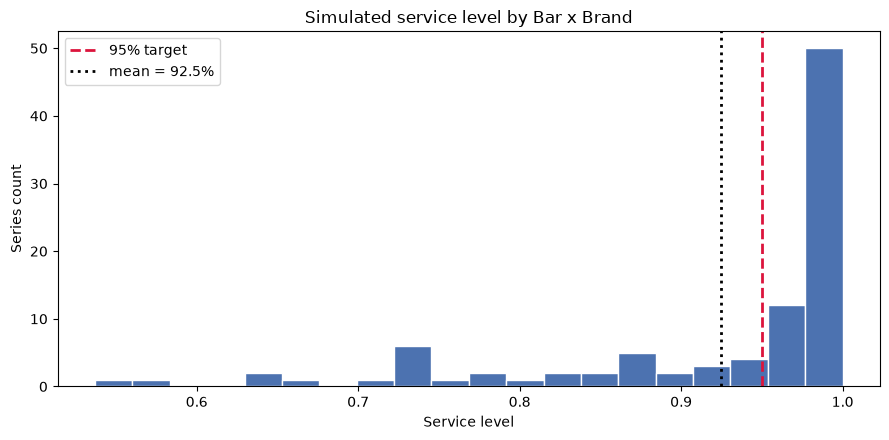

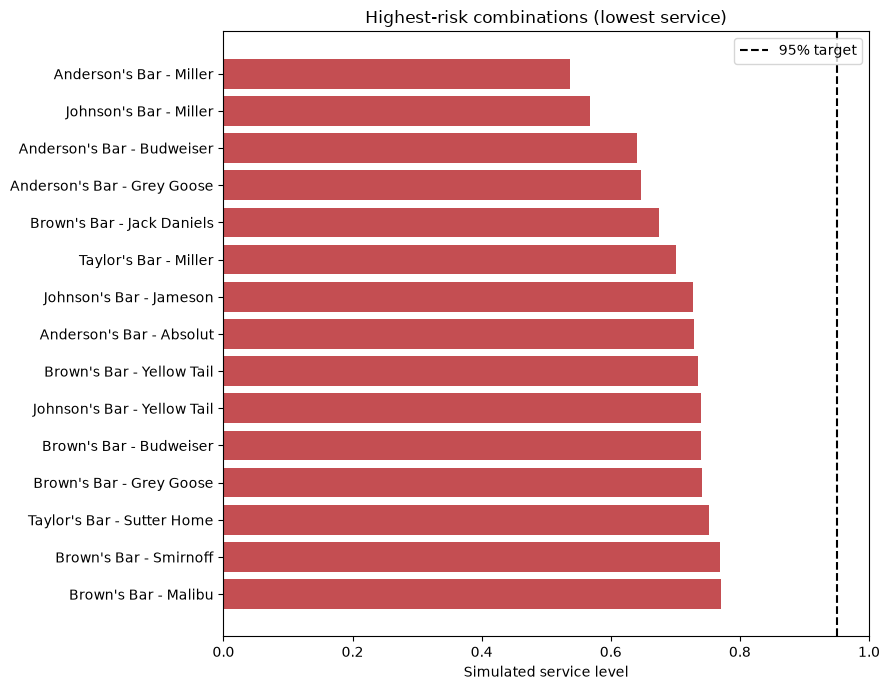

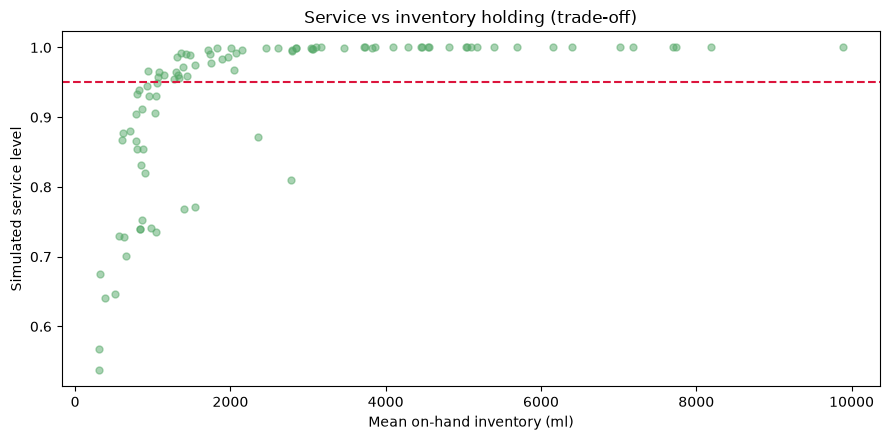

In [107]:
report_dir = PROJECT_ROOT / "report"
report_dir.mkdir(exist_ok=True)

svc_series = inventory_simulation["service_level"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(svc_series, bins=20, color="#4C72B0", edgecolor="white")
ax.axvline(0.95, color="crimson", ls="--", lw=2, label="95% target")
ax.axvline(svc_series.mean(), color="black", ls=":", lw=2, label=f"mean = {svc_series.mean():.1%}")
ax.set_title("Simulated service level by Bar x Brand")
ax.set_xlabel("Service level"); ax.set_ylabel("Series count"); ax.legend()
fig.tight_layout(); fig.savefig(report_dir / "fig_service_distribution.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
top = high_risk.iloc[::-1]
ax.barh(
    top["Bar Name"] + " - " + top["Brand Name"],
    top["service_level"], color="#C44E52"
)
ax.axvline(0.95, color="black", ls="--", lw=1.5, label="95% target")
ax.set_xlim(0, 1)
ax.set_xlabel("Simulated service level")
ax.set_title("Highest-risk combinations (lowest service)")
ax.legend(); fig.tight_layout()
fig.savefig(report_dir / "fig_high_risk.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(
    kpi["mean_on_hand_ml"], kpi["service_level"],
    alpha=0.5, s=25, color="#55A868"
)
ax.axhline(0.95, color="crimson", ls="--", lw=1.5)
ax.set_xlabel("Mean on-hand inventory (ml)")
ax.set_ylabel("Simulated service level")
ax.set_title("Service vs inventory holding (trade-off)")
fig.tight_layout(); fig.savefig(report_dir / "fig_service_vs_inventory.png", dpi=120)
plt.show()


### 12.8 Save final outputs

In [108]:
high_risk.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "high_risk_series.csv"),
    index=False
)
inventory_heavy.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "inventory_heavy_series.csv"),
    index=False
)
kpi.to_csv(
    str(PROJECT_ROOT / "data" / "processed" / "final_kpis.csv"),
    index=False
)
print("Saved: high_risk_series.csv, inventory_heavy_series.csv, final_kpis.csv")


Saved: high_risk_series.csv, inventory_heavy_series.csv, final_kpis.csv
